# **Advanced Apex Project-1 (M.Sc. DS & AI)**

## **Week-5 Progress Submission Notebook**

## **Predicting Credit Risk:**

**A Baseline Classification Model for German Credit Applicants**

### **Problem Statement**

Financial institutions face the challenge of accurately assessing the creditworthiness of loan
applicants. Misclassifying a 'Bad' credit risk as 'Good' can lead to significant financial losses,
while incorrectly rejecting a 'Good' applicant can result in missed business opportunities. The
problem is to build a predictive model that can effectively discriminate between 'Good' and 'Bad'
credit applicants based on their provided profile information, minimizing the higher cost
associated with false positives (approving a bad risk).


### **Business Goal**

The primary business objective is to develop a reliable baseline machine learning model for credit
risk assessment. This model aims to:



*   **Improve credit decision-making**: Provide adata-driven approach to classify applicants.
*   **Mitigate financial risk:** Reduce losses incurred from approving high-risk applicants by
accurately identifying 'Bad' credit risks.
*   **Establish a performance benchmark:** Create aninitial model that serves as a baseline for
future, more sophisticated credit risk models, with a focus on optimizing metrics aligned
with the given cost matrix (e.g., minimizing false positives for 'Bad' risks).

### **1. Dataset Overview**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pip install ucimlrepo

In [5]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
german_credit = fetch_ucirepo(id=144)

# data (as pandas DataFrames)
X = german_credit.data.features
y = german_credit.data.targets

# variable information
print(german_credit.variables)

           name     role         type     demographic  \
0    Attribute1  Feature  Categorical            None   
1    Attribute2  Feature      Integer            None   
2    Attribute3  Feature  Categorical            None   
3    Attribute4  Feature  Categorical            None   
4    Attribute5  Feature      Integer            None   
5    Attribute6  Feature  Categorical            None   
6    Attribute7  Feature  Categorical           Other   
7    Attribute8  Feature      Integer            None   
8    Attribute9  Feature  Categorical  Marital Status   
9   Attribute10  Feature  Categorical            None   
10  Attribute11  Feature      Integer            None   
11  Attribute12  Feature  Categorical            None   
12  Attribute13  Feature      Integer             Age   
13  Attribute14  Feature  Categorical            None   
14  Attribute15  Feature  Categorical           Other   
15  Attribute16  Feature      Integer            None   
16  Attribute17  Feature  Categ

# **2. Data Inspection and Audit**

In [6]:
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print("\n--- Features (X) Information ---")
print("Columns:", X.columns.tolist())
print("Data Types:")
display(X.dtypes)
print("Missing Values:")
display(X.isnull().sum())

print("\n--- Target (y) Information ---")
print("Columns:", y.columns.tolist())
print("Data Types:")
display(y.dtypes)
print("Missing Values:")
display(y.isnull().sum())

Shape of features (X): (1000, 20)
Shape of target (y): (1000, 1)

--- Features (X) Information ---
Columns: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']
Data Types:


,0
Attribute1,object
Attribute2,int64
Attribute3,object
Attribute4,object
Attribute5,int64
Attribute6,object
Attribute7,object
Attribute8,int64
Attribute9,object
Attribute10,object


Missing Values:


,0
Attribute1,0
Attribute2,0
Attribute3,0
Attribute4,0
Attribute5,0
Attribute6,0
Attribute7,0
Attribute8,0
Attribute9,0
Attribute10,0



--- Target (y) Information ---
Columns: ['class']
Data Types:


,0
class,int64


Missing Values:


,0
class,0


### Detailed Variable Information

In [7]:
display(german_credit.variables)

,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,None,Status of existing checking account,None,no
1,Attribute2,Feature,Integer,None,Duration,months,no
2,Attribute3,Feature,Categorical,None,Credit history,None,no
3,Attribute4,Feature,Categorical,None,Purpose,None,no
4,Attribute5,Feature,Integer,None,Credit amount,None,no
5,Attribute6,Feature,Categorical,None,Savings account/bonds,None,no
6,Attribute7,Feature,Categorical,Other,Present employment since,None,no
7,Attribute8,Feature,Integer,None,Installment rate in percentage of disposable i...,None,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,None,no
9,Attribute10,Feature,Categorical,None,Other debtors / guarantors,None,no


### Combined Dataset Inspection

In [8]:
# Combine features (X) and target (y) into a single DataFrame for comprehensive analysis
df = pd.concat([X, y], axis=1)

print("Shape of combined DataFrame (df):")
display(df.shape)

Shape of combined DataFrame (df):


(1000, 21)

In [9]:
print("Data Types of combined DataFrame (df):")
display(df.dtypes)

Data Types of combined DataFrame (df):


,0
Attribute1,object
Attribute2,int64
Attribute3,object
Attribute4,object
Attribute5,int64
Attribute6,object
Attribute7,object
Attribute8,int64
Attribute9,object
Attribute10,object


In [10]:
print("First 5 rows of combined DataFrame (df):")
display(df.head())

First 5 rows of combined DataFrame (df):


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [11]:
print("Info of combined DataFrame (df):")
df.info()

Info of combined DataFrame (df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  Attribute19  1000 non-null   object


In [12]:
print("Descriptive statistics of combined DataFrame (df):")
display(df.describe())

Descriptive statistics of combined DataFrame (df):


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [13]:
print("Value counts for the target variable 'class':")
display(df['class'].value_counts())

Value counts for the target variable 'class':


,count
class,
1,700
2,300


From the `df.describe()` output, we can observe the summary statistics for numerical features, such as `Attribute2` (Duration), `Attribute5` (Credit amount), and `Attribute13` (Age). This gives us an idea of their range, mean, and standard deviation.

The `df['class'].value_counts()` output shows the distribution of the target variable. We can see that there are 700 'Good' credit applicants (represented by 1) and 300 'Bad' credit applicants (represented by 2), indicating a class imbalance.

## Initial Understanding & Observations

The dataset contains 1000 observations, with 20 features and a single target variable (class).

A significant number of features are categorical, represented by codes (e.g., 'A11', 'A32'), which
will require proper encoding for most machine learning algorithms.

The problem is a binary classification task. The target variable needs to be mapped to a standard
numerical representation (e.g., 0 and 1).

The project description highlights a crucial cost matrix: misclassifying a 'Bad' credit risk as 'Good'
is 5 times more costly than misclassifying a 'Good' risk as 'Bad'. This implies that traditional
accuracy might not be the most appropriate primary evaluation metric; precision, recall, and F1-
score, especially for the 'Bad' class, or custom cost-sensitive metrics, will be important.

There are no reported missing values according to the dataset metadata.

### Class Distribution of Target Variable

The target variable `y` needs to be analyzed for class imbalance. A balanced dataset is crucial for model training, especially given the cost matrix where misclassifying 'Bad' credit applicants is more expensive.

In [14]:
# Check class distribution
class_distribution = y['class'].value_counts()
print("Class Distribution:\n", class_distribution)
print("\nPercentage of each class:\n", y['class'].value_counts(normalize=True) * 100)

Class Distribution:
 class
1    700
2    300
Name: count, dtype: int64

Percentage of each class:
 class
1    70.0
2    30.0
Name: proportion, dtype: float64


### Identifying Numerical and Categorical Features

Based on `german_credit.variables` and initial inspection, we can identify which features are numerical and which are categorical. This is important for applying appropriate preprocessing steps like one-hot encoding for categorical features and potential scaling for numerical features.

In [15]:
# Separate numerical and categorical features
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"Numerical columns: {numerical_cols.tolist()}")
print(f"Categorical columns: {categorical_cols.tolist()}")

Numerical columns: ['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18']
Categorical columns: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']


### Unique Values in Categorical Features

Many categorical features are represented by codes (e.g., 'A11', 'A32'). Examining the unique values for these features will provide a better understanding of their diversity and help confirm if they are indeed categorical and how many unique categories each feature has, which is important for encoding strategies.

In [16]:
for col in categorical_cols:
    print(f"\nUnique values for {col}:\n{X[col].unique()}")
    print(f"Number of unique values for {col}: {X[col].nunique()}")


Unique values for Attribute1:
['A11' 'A12' 'A14' 'A13']
Number of unique values for Attribute1: 4

Unique values for Attribute3:
['A34' 'A32' 'A33' 'A30' 'A31']
Number of unique values for Attribute3: 5

Unique values for Attribute4:
['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']
Number of unique values for Attribute4: 10

Unique values for Attribute6:
['A65' 'A61' 'A63' 'A64' 'A62']
Number of unique values for Attribute6: 5

Unique values for Attribute7:
['A75' 'A73' 'A74' 'A71' 'A72']
Number of unique values for Attribute7: 5

Unique values for Attribute9:
['A93' 'A92' 'A91' 'A94']
Number of unique values for Attribute9: 4

Unique values for Attribute10:
['A101' 'A103' 'A102']
Number of unique values for Attribute10: 3

Unique values for Attribute12:
['A121' 'A122' 'A124' 'A123']
Number of unique values for Attribute12: 4

Unique values for Attribute14:
['A143' 'A141' 'A142']
Number of unique values for Attribute14: 3

Unique values for Attribute15:
['A152' 'A153' 'A

### Duplicate Checks

It's important to check for duplicate rows in the dataset, as these can bias model training and evaluation. We will identify and count any exact duplicate rows.

In [17]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Displaying first 5 duplicate rows (if any):")
    display(df[df.duplicated(keep=False)].head())
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### Outlier Analysis

Outliers can significantly impact model performance. We will use box plots to visualize potential outliers in numerical features and calculate the Interquartile Range (IQR) to quantify them.

Box plots for numerical features (Outlier Detection):


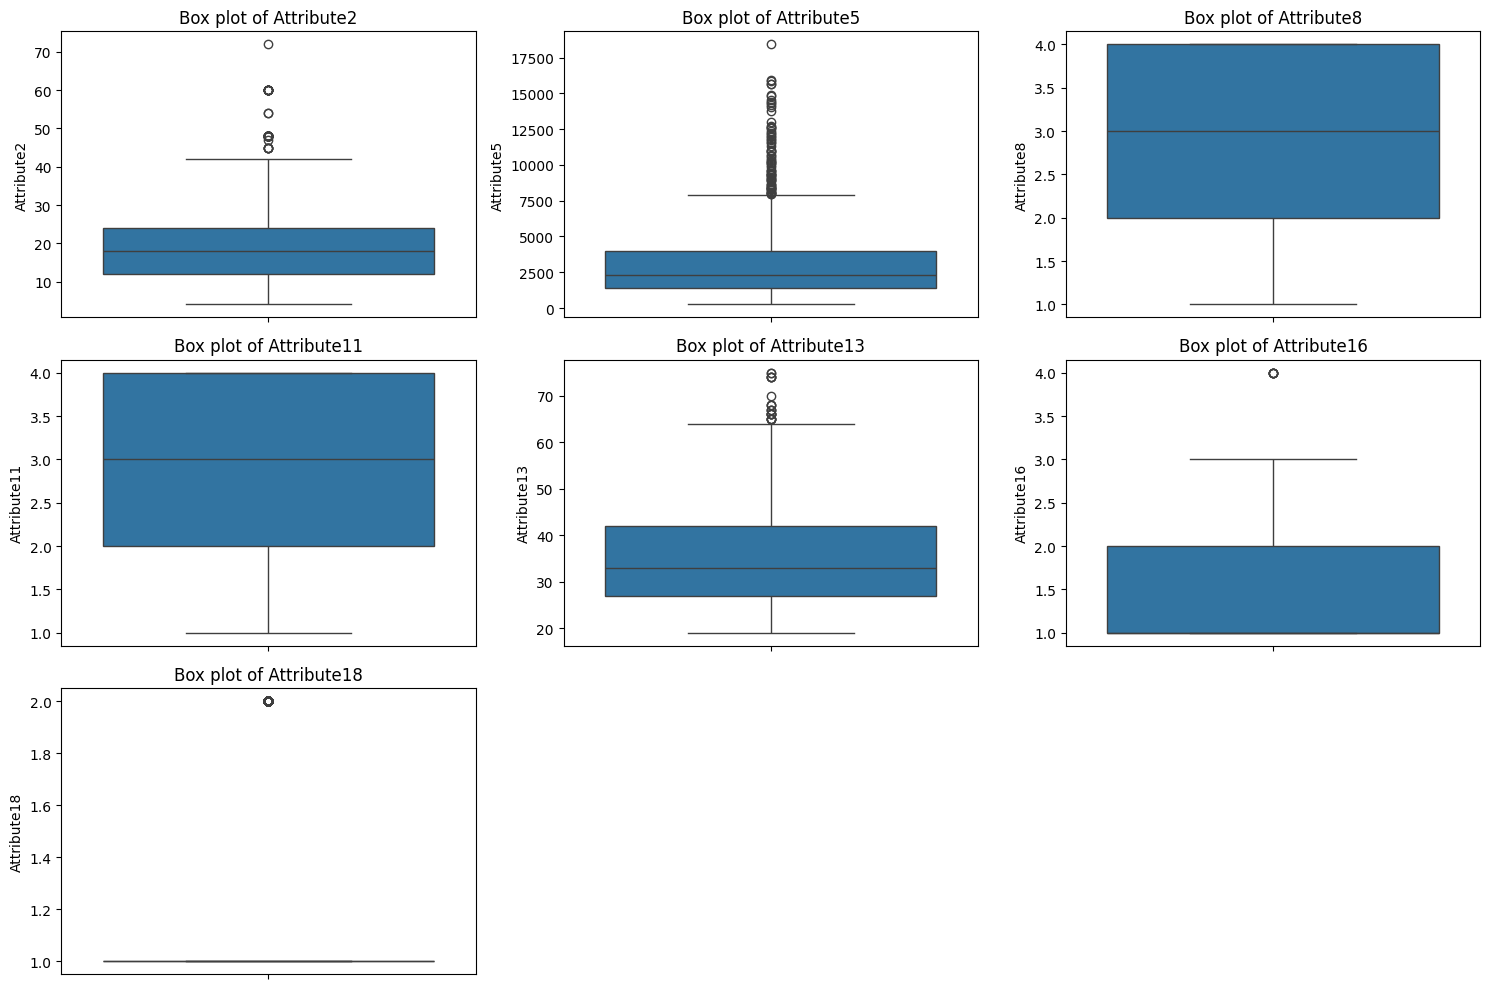

In [18]:
print("Box plots for numerical features (Outlier Detection):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [19]:
# Quantify outliers using IQR method
print("\nOutlier count for each numerical feature (values outside 1.5*IQR):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")


Outlier count for each numerical feature (values outside 1.5*IQR):
Attribute2: 70 outliers
Attribute5: 72 outliers
Attribute8: 0 outliers
Attribute11: 0 outliers
Attribute13: 23 outliers
Attribute16: 6 outliers
Attribute18: 155 outliers


### Skewness Analysis

Skewness indicates the asymmetry of the probability distribution of a real-valued random variable about its mean. Understanding skewness is important for some models that assume normal distribution or can be sensitive to skewed data. We will calculate the skewness coefficient and visualize distributions using histograms.

In [20]:
print("\nSkewness for numerical features:")
display(df[numerical_cols].skew())


Skewness for numerical features:


,0
Attribute2,1.094184
Attribute5,1.949628
Attribute8,-0.531348
Attribute11,-0.272570
Attribute13,1.020739
Attribute16,1.272576
Attribute18,1.909445


Histograms for numerical features (Distribution & Skewness visualization):


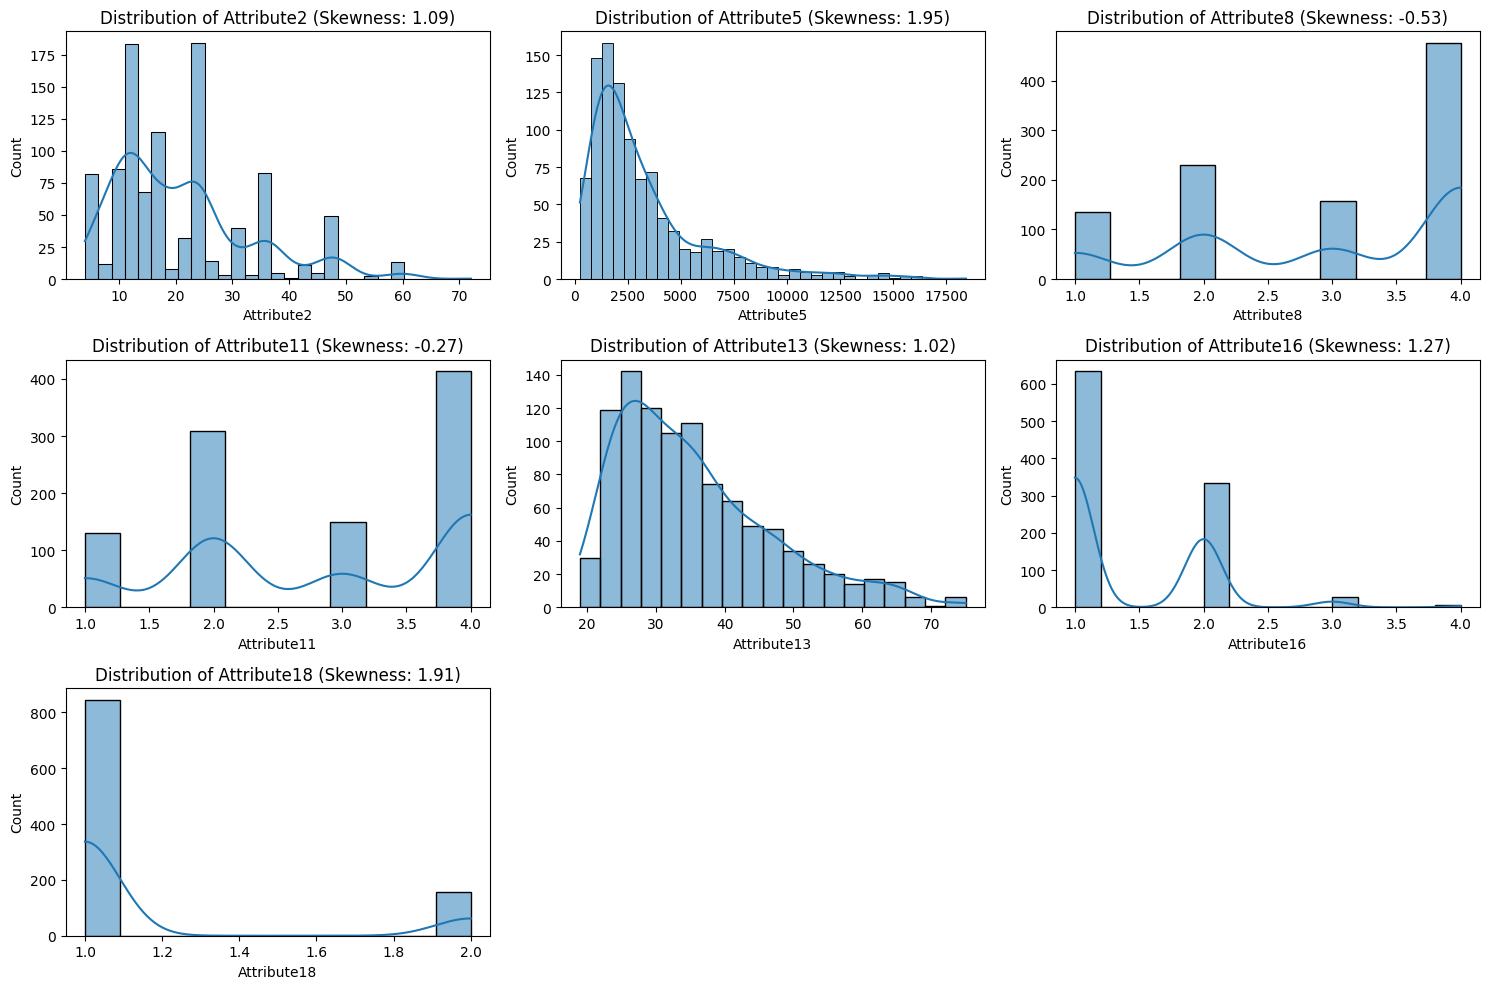

In [21]:
print("Histograms for numerical features (Distribution & Skewness visualization):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (Skewness: {df[col].skew():.2f})')
plt.tight_layout()
plt.show()

### Visualizing Target Variable Distribution

It is crucial to understand the distribution of the target variable ('class') to assess class imbalance, which is vital for this credit risk prediction problem.

/tmp/ipykernel_595/2000505802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


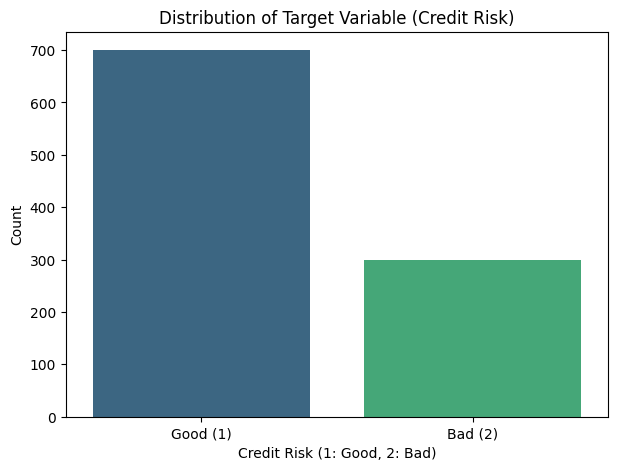

In [22]:
plt.figure(figsize=(7, 5))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Credit Risk)')
plt.xlabel('Credit Risk (1: Good, 2: Bad)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Good (1)', 'Bad (2)'])
plt.show()

### Visualizing Important Numerical Features

Let's visualize the distributions of key numerical features such as `Attribute2` (Duration), `Attribute5` (Credit amount), and `Attribute13` (Age) and their relationship with the target variable.

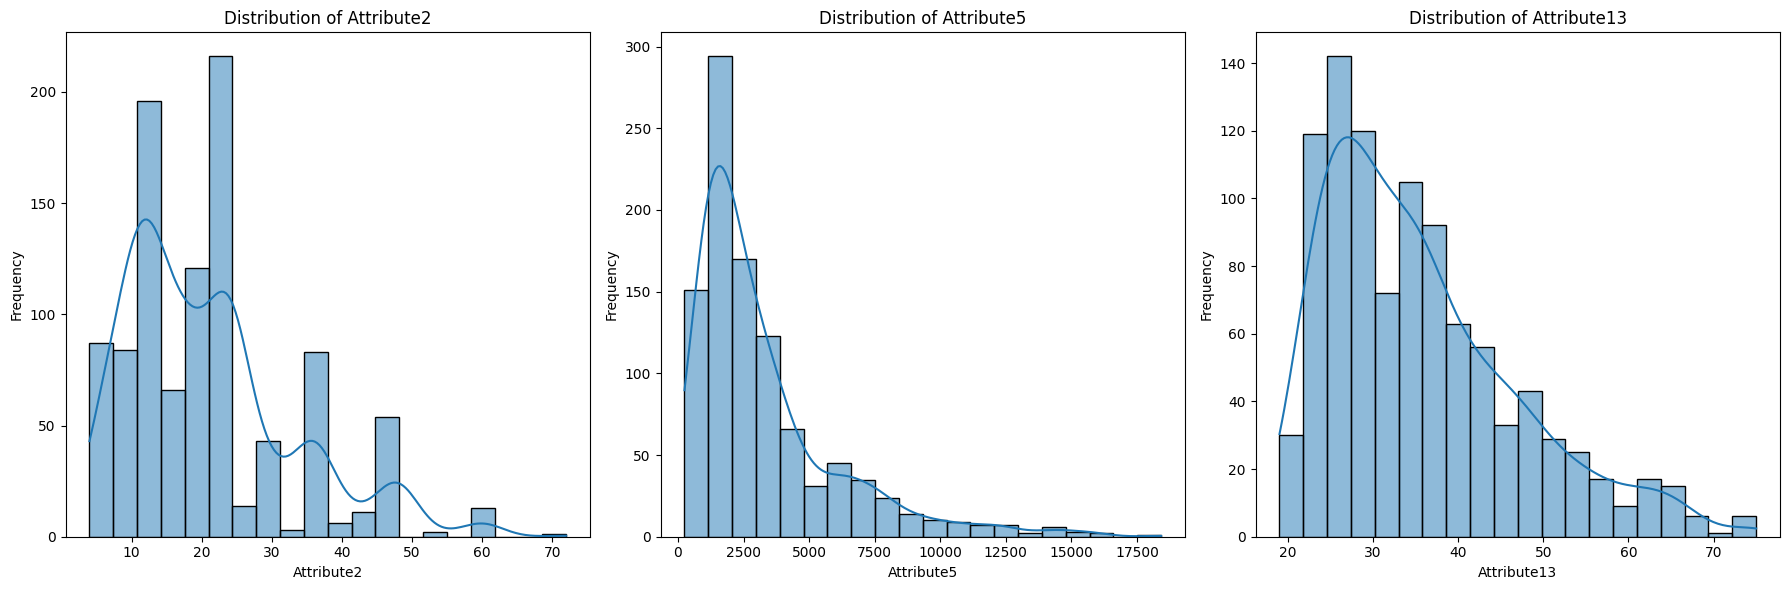

/tmp/ipykernel_595/1402306953.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='muted')
/tmp/ipykernel_595/1402306953.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='muted')
/tmp/ipykernel_595/1402306953.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='muted')


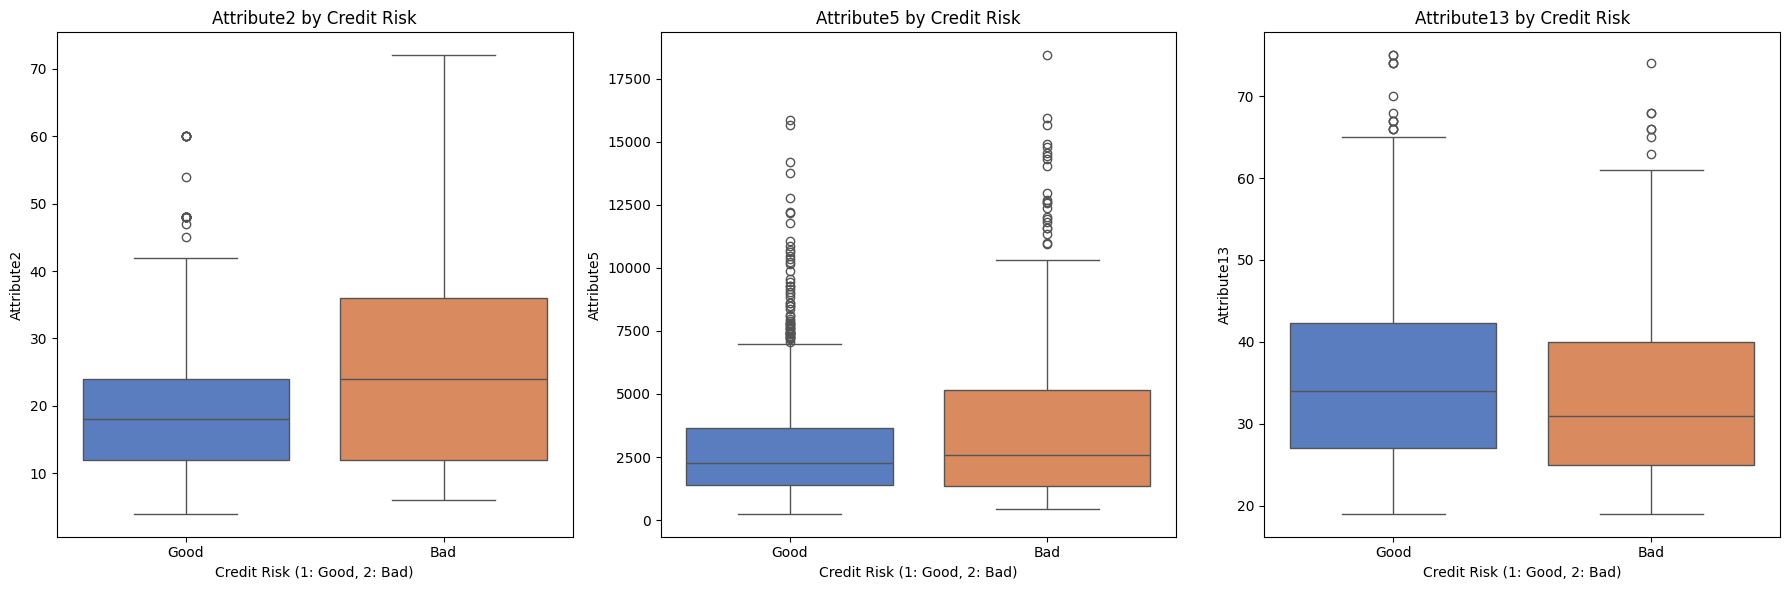

In [23]:
important_numerical_features = ['Attribute2', 'Attribute5', 'Attribute13']

plt.figure(figsize=(18, 6))
for i, col in enumerate(important_numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for i, col in enumerate(important_numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='class', y=col, data=df, palette='muted')
    plt.title(f'{col} by Credit Risk')
    plt.xlabel('Credit Risk (1: Good, 2: Bad)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['Good', 'Bad'])
plt.tight_layout()
plt.show()

### Visualizing Important Categorical Features

Now, let's look at the distributions of important categorical features like `Attribute1` (Status of existing checking account), `Attribute3` (Credit history), `Attribute4` (Purpose), and `Attribute9` (Personal status and sex), and how their categories are distributed across the target variable.

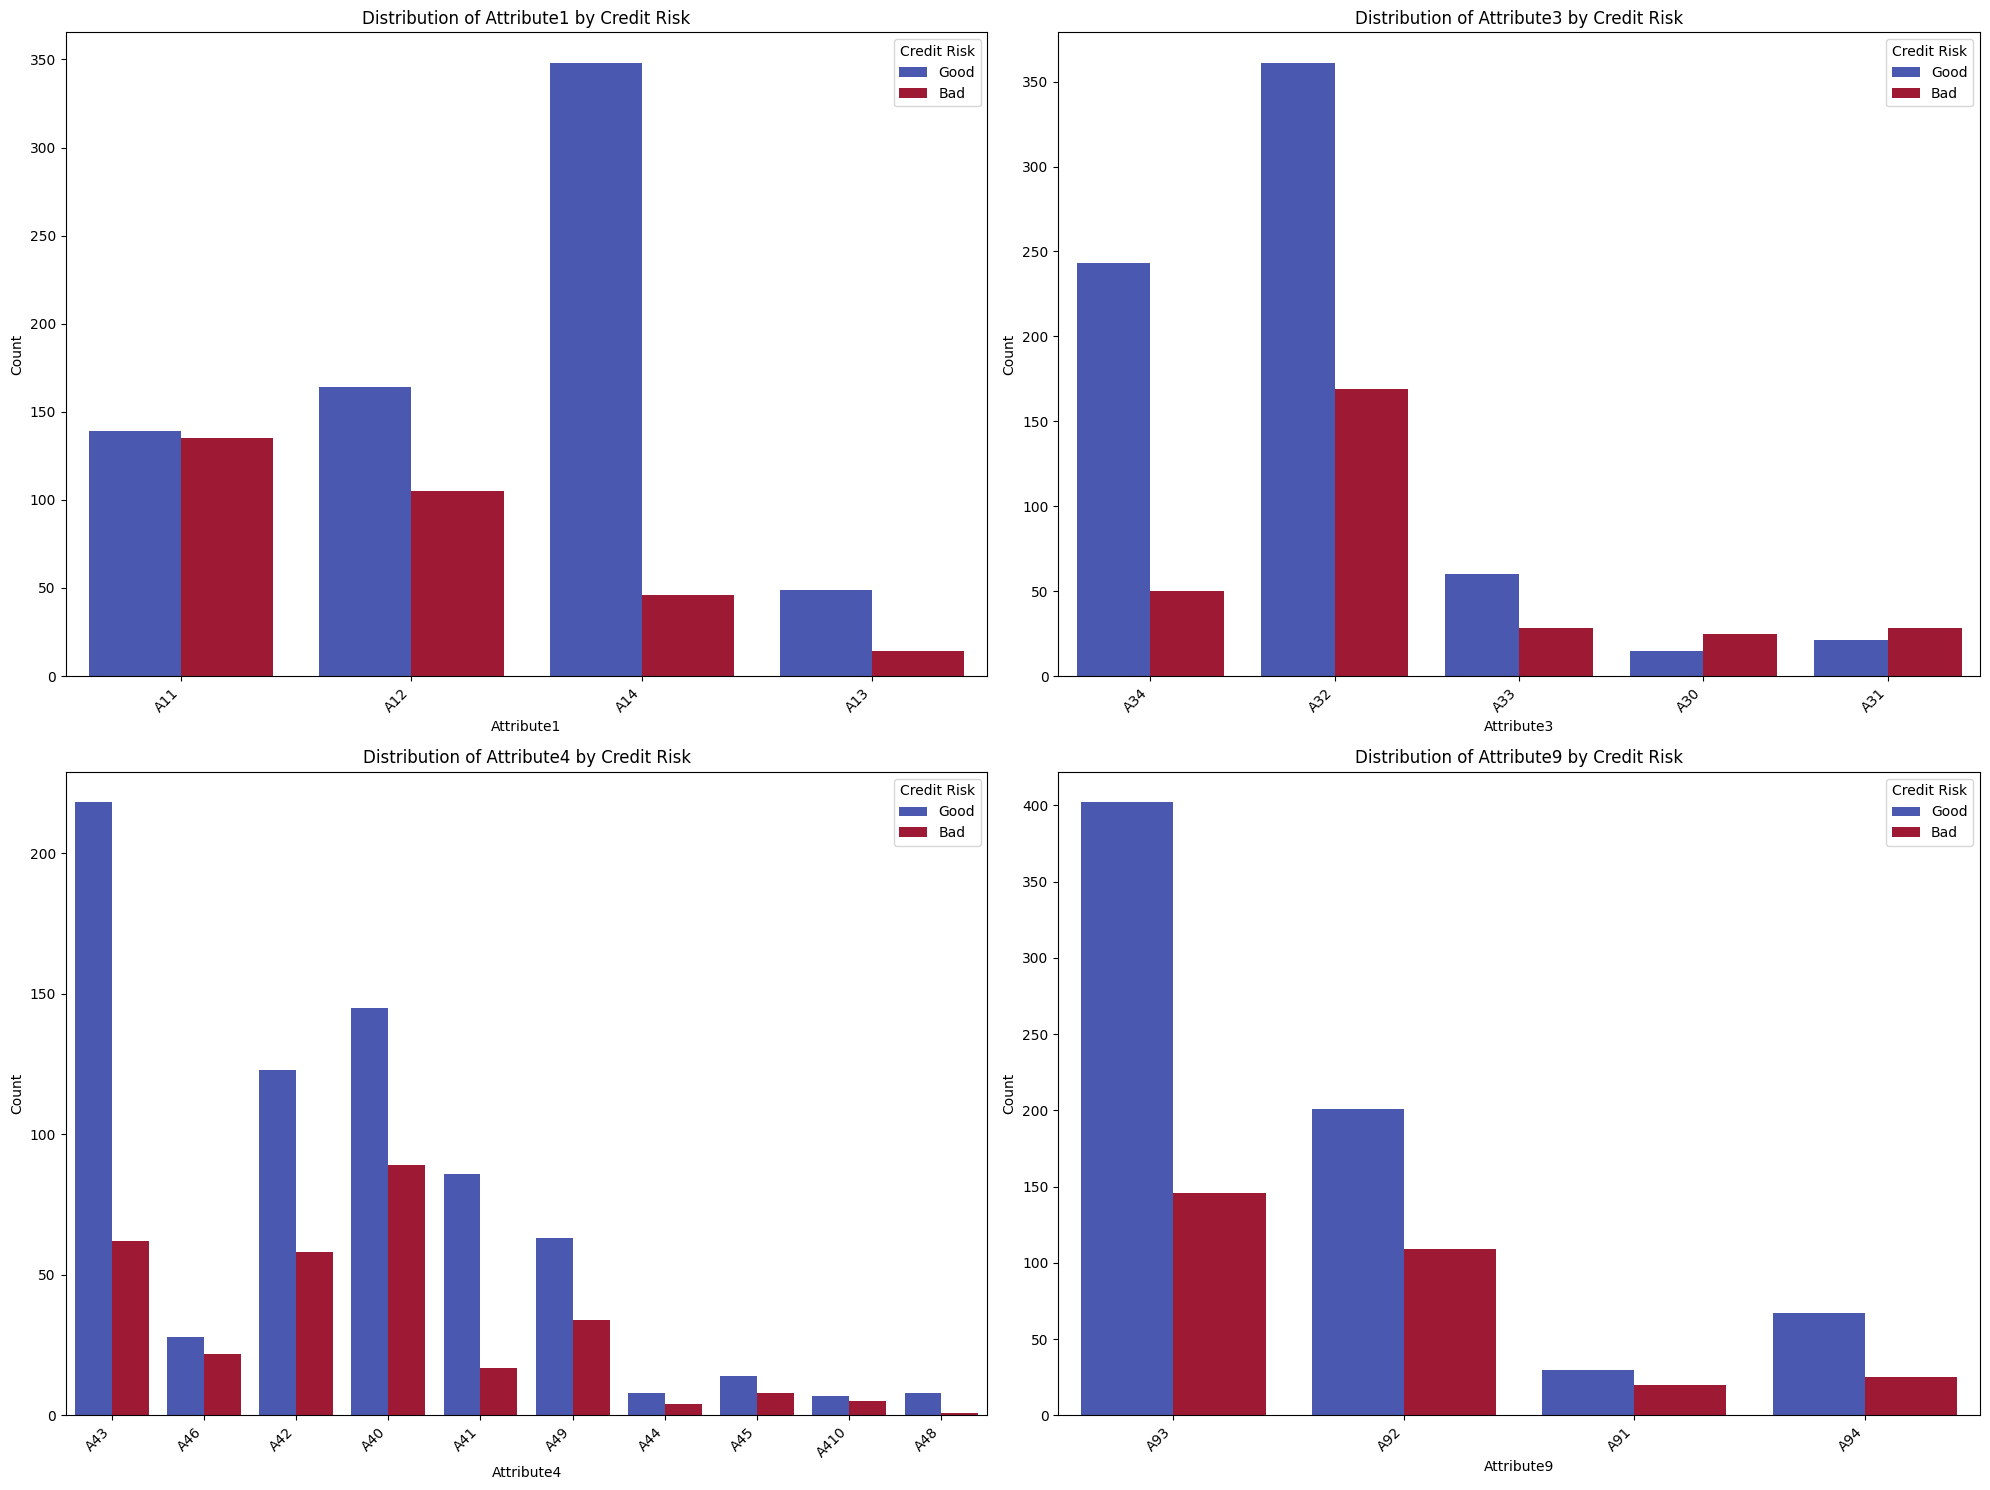

In [24]:
important_categorical_features = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute9']

plt.figure(figsize=(20, 15))
for i, col in enumerate(important_categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=col, hue='class', data=df, palette='coolwarm')
    plt.title(f'Distribution of {col} by Credit Risk')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Credit Risk', labels=['Good', 'Bad'])
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Metric Interpretation in the Context of Misclassification Costs

Given the problem statement's emphasis on the high cost of misclassifying a 'Bad' credit risk as 'Good' (5 times more costly than the reverse), our future metric interpretations will explicitly prioritize this business objective.

Key considerations for model evaluation and metric selection will include:

*   **False Negatives (FN):** These represent 'Bad' credit applicants incorrectly classified as 'Good'. Minimizing FNs will be paramount due to their high financial cost.
*   **Recall (Sensitivity) for the 'Bad' Class (Class 2):** High recall for the 'Bad' class means the model is effective at identifying most of the actual 'Bad' applicants, thus reducing costly false positives.
*   **Precision for the 'Good' Class (Class 1):** While prioritizing 'Bad' class recall, we also need to maintain reasonable precision for the 'Good' class to avoid rejecting too many creditworthy applicants.
*   **F1-Score and Custom Cost-Sensitive Metrics:** We will explore F1-score and potentially develop custom metrics that directly incorporate the specified cost matrix to provide a more business-relevant evaluation of model performance.

All subsequent model building and evaluation steps will aim to strike a balance that reflects this cost asymmetry, ensuring that the model's performance aligns with the financial institution's risk mitigation goals.

# **3. Data Preprocessing**

### Target Variable Remapping

Many machine learning algorithms expect binary target variables to be represented as 0 and 1. Currently, our 'class' variable is encoded as 1 (Good) and 2 (Bad). We will remap 'Good' to 0 and 'Bad' to 1 to align with common practices, especially when dealing with cost-sensitive learning where the positive class (often the rare or more costly class, 'Bad' credit in our case) is typically represented by 1.

In [25]:
# Remap 'class' from (1, 2) to (0, 1)
df['class'] = df['class'].map({1: 0, 2: 1})

print("New class distribution after remapping:")
display(df['class'].value_counts())
print("First 5 rows of df after remapping target:")
display(df.head())

New class distribution after remapping:


,count
class,
0,700
1,300


First 5 rows of df after remapping target:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


### Categorical Feature Encoding (One-Hot Encoding)

Most machine learning algorithms cannot directly work with categorical data. One common technique to convert these features into a numerical format is **One-Hot Encoding**. This process creates new binary (dummy) variables for each category within a categorical feature. We will apply this to our `categorical_cols`.

In [26]:
# Apply One-Hot Encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after One-Hot Encoding:")
display(df_encoded.shape)

print("First 5 rows of DataFrame after One-Hot Encoding:")
display(df_encoded.head())

Shape of DataFrame after One-Hot Encoding:


(1000, 49)

First 5 rows of DataFrame after One-Hot Encoding:


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,class,Attribute1_A12,Attribute1_A13,...,Attribute12_A124,Attribute14_A142,Attribute14_A143,Attribute15_A152,Attribute15_A153,Attribute17_A172,Attribute17_A173,Attribute17_A174,Attribute19_A192,Attribute20_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


### Scaling Numerical Features

Many machine learning algorithms, particularly those based on distance metrics (e.g., K-Nearest Neighbors, Support Vector Machines) or gradient descent (e.g., Logistic Regression, Neural Networks), are sensitive to the scale and range of input features. Features with larger values might dominate the learning process.

**Standardization** (using `StandardScaler`) transforms the data so that it has a mean of 0 and a standard deviation of 1. This helps in bringing all numerical features to a comparable scale without distorting differences in the ranges of values.

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns in the encoded DataFrame
# Ensure 'numerical_cols' are still present after encoding (they should be, as they are not categorical)

# Filter numerical_cols to only include those present in df_encoded after one-hot encoding
# (in case some were dropped or modified, though unlikely for numerical ones)
scaled_numerical_cols = [col for col in numerical_cols if col in df_encoded.columns]

df_encoded[scaled_numerical_cols] = scaler.fit_transform(df_encoded[scaled_numerical_cols])

print("First 5 rows of DataFrame after numerical feature scaling:")
display(df_encoded.head())

print("Descriptive statistics of scaled numerical features:")
display(df_encoded[scaled_numerical_cols].describe())

First 5 rows of DataFrame after numerical feature scaling:


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,class,Attribute1_A12,Attribute1_A13,...,Attribute12_A124,Attribute14_A142,Attribute14_A143,Attribute15_A152,Attribute15_A153,Attribute17_A172,Attribute17_A173,Attribute17_A174,Attribute19_A192,Attribute20_A202
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-0.428290,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.428290,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,2.334869,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,1.750384,1.634247,-0.870183,1.046987,0.831502,-0.704926,2.334869,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,0.256953,0.566664,0.024147,1.046987,1.535122,1.027079,2.334869,1,False,False,...,True,False,True,False,True,False,True,False,False,False


Descriptive statistics of scaled numerical features:


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.136868e-16,6.661338e-17,1.012523e-16,-1.776357e-16,5.329071e-17,-9.414691e-17,-1.065814e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.402415e+00,-1.070865e+00,-1.764514e+00,-1.672459e+00,-1.455261e+00,-7.049260e-01,-4.282896e-01
25%,-7.386675e-01,-6.754833e-01,-8.701833e-01,-7.659773e-01,-7.516417e-01,-7.049260e-01,-4.282896e-01
50%,-2.408572e-01,-3.373443e-01,2.414692e-02,1.405047e-01,-2.239269e-01,-7.049260e-01,-4.282896e-01
75%,2.569531e-01,2.484620e-01,9.184772e-01,1.046987e+00,5.676451e-01,1.027079e+00,-4.282896e-01
max,4.239436e+00,5.370789e+00,9.184772e-01,1.046987e+00,3.470076e+00,4.491089e+00,2.334869e+00


### Data Preprocessing Decisions and Observations

Following the data preprocessing steps, we have transformed the dataset into a format suitable for machine learning models, and several key insights emerged:

1.  **Target Variable Remapping (`class`):**
    *   The remapping of the target variable from (1: Good, 2: Bad) to (0: Good, 1: Bad) is crucial. It aligns the dataset with standard machine learning conventions where '1' often represents the positive or 'event' class, which in our cost-sensitive context, is the 'Bad' credit risk. This prepares the data for models that naturally interpret '1' as the class of interest, especially for metrics like recall, precision, and F1-score focused on the minority (or more costly) class.

2.  **Categorical Feature Encoding (One-Hot Encoding):**
    *   One-hot encoding successfully converted the 13 categorical features into numerical representations. This process significantly **increased the dimensionality** of our dataset (from 21 columns to 49 columns, including the target). This increased feature space is now accessible to algorithms but also highlights a potential need for feature selection or dimensionality reduction in later stages to combat the curse of dimensionality.
    *   The `drop_first=True` argument in `pd.get_dummies` prevented multicollinearity among the dummy variables, which is important for some linear models.

3.  **Numerical Feature Scaling (`StandardScaler`):**
    *   Applying `StandardScaler` to the 7 numerical features normalized their distributions to have a mean of 0 and a standard deviation of 1. This step is vital for algorithms sensitive to feature scales, such as Logistic Regression, Support Vector Machines, Neural Networks, and K-Nearest Neighbors. It ensures that features with larger original ranges (e.g., `Attribute5` - Credit amount) do not disproportionately influence the model compared to features with smaller ranges.
    *   The `describe()` output for scaled features confirms that their mean is near zero and standard deviation is near one, validating the scaling process.

In summary, the preprocessing has effectively prepared the dataset for modeling by handling categorical data, normalizing numerical scales, and aligning the target variable. The increase in dimensionality and the initial class imbalance remain important considerations for subsequent model building and evaluation.

# **4. Exploratory Data Analysis**

### **Visualizing All Feature Distributions**

To get a comprehensive understanding of the dataset, let's visualize the distributions of all numerical features using histograms and all categorical features using bar plots. This will help us observe their individual patterns, skewness, and category frequencies.

#### Numerical Feature Distributions (Histograms)

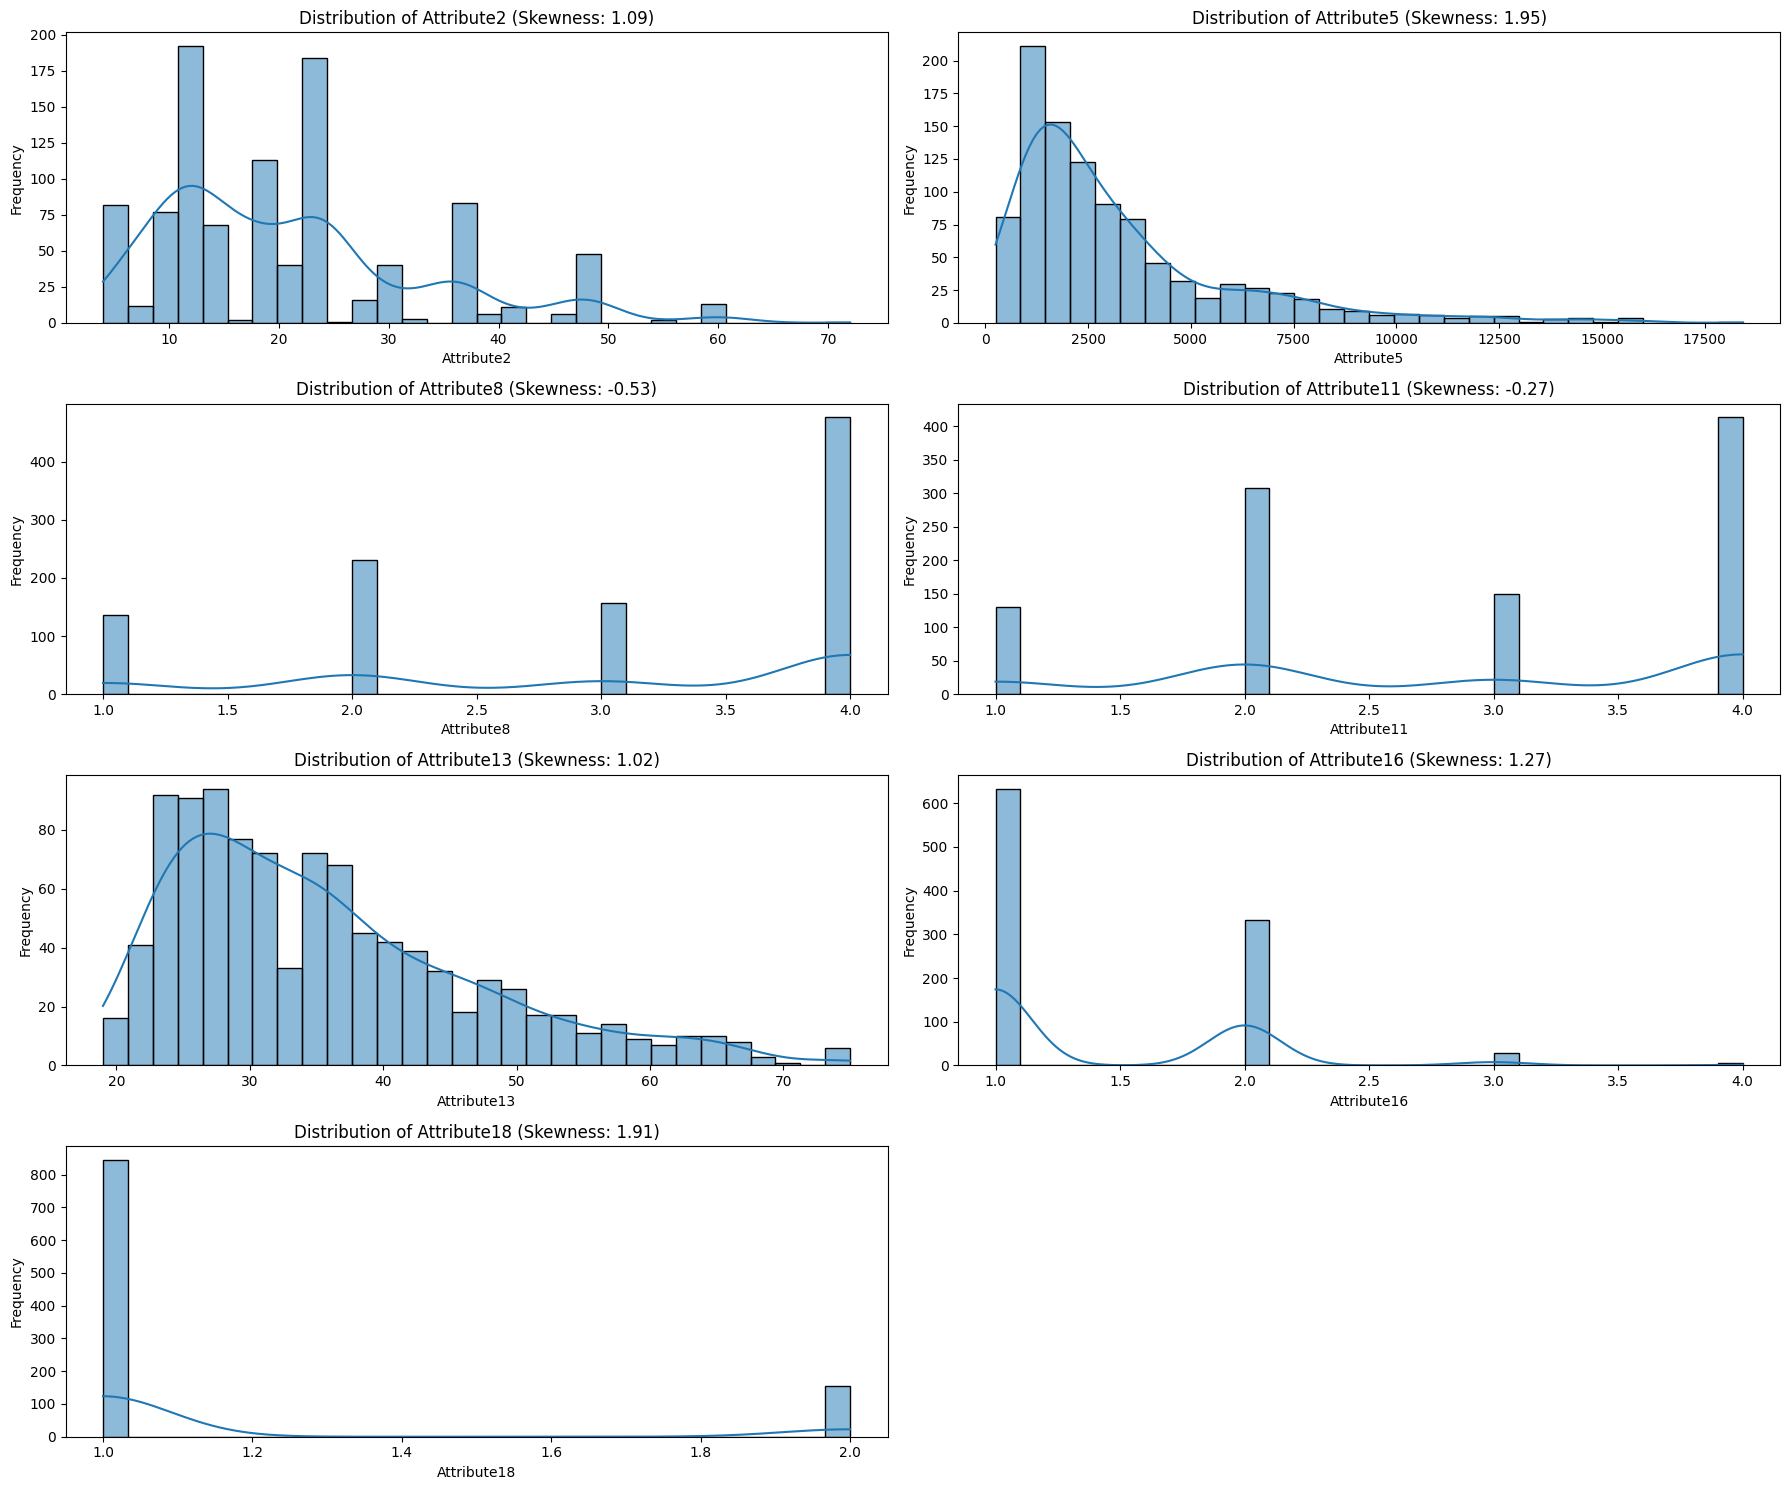

In [28]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)  # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Skewness: {df[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Categorical Feature Distributions (Bar Plots)

/tmp/ipykernel_595/975609843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_595/975609843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_595/975609843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_595/975609843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is dep

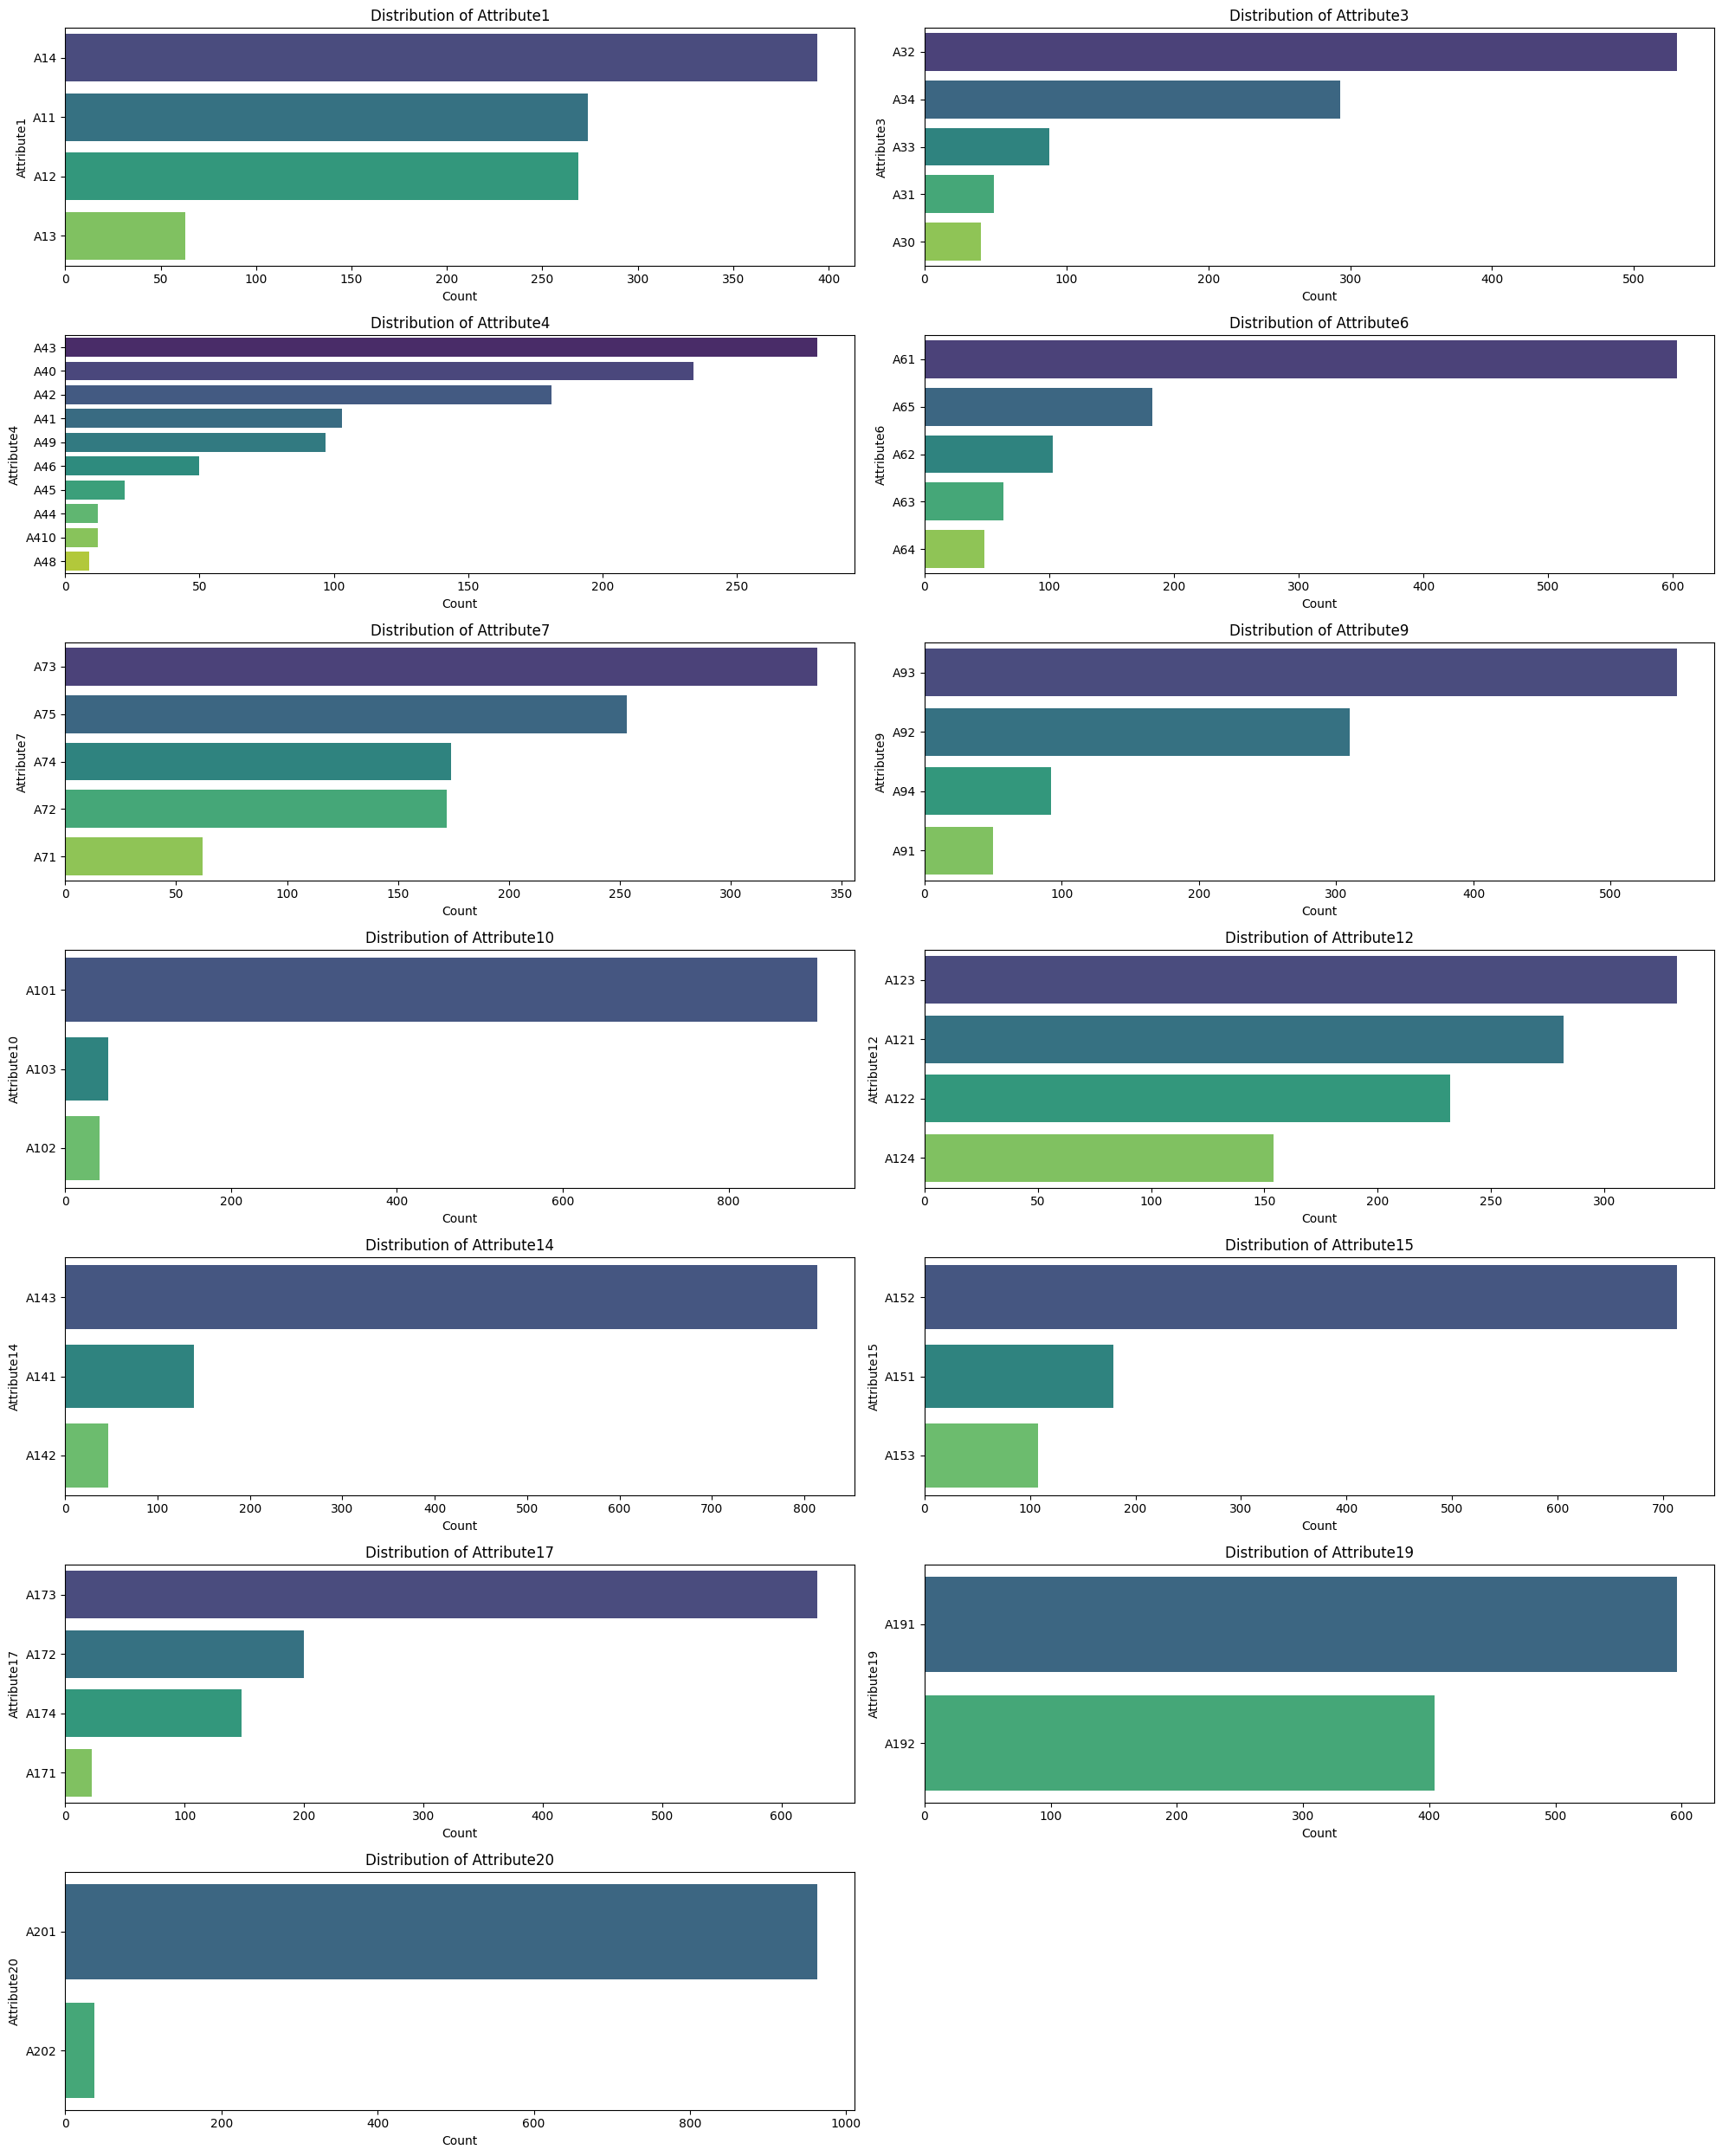

In [29]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(7, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Analyzing Relationships between Features and Target Variable**

Now, let's analyze the relationships between our features and the target variable (`class`). This will help us identify features that are most predictive of credit risk.

#### Correlation Matrix for Numerical Features

A correlation matrix is a great way to visualize the linear relationships between numerical variables. We'll include the target variable (`class`) to see how strongly each numerical feature correlates with credit risk.

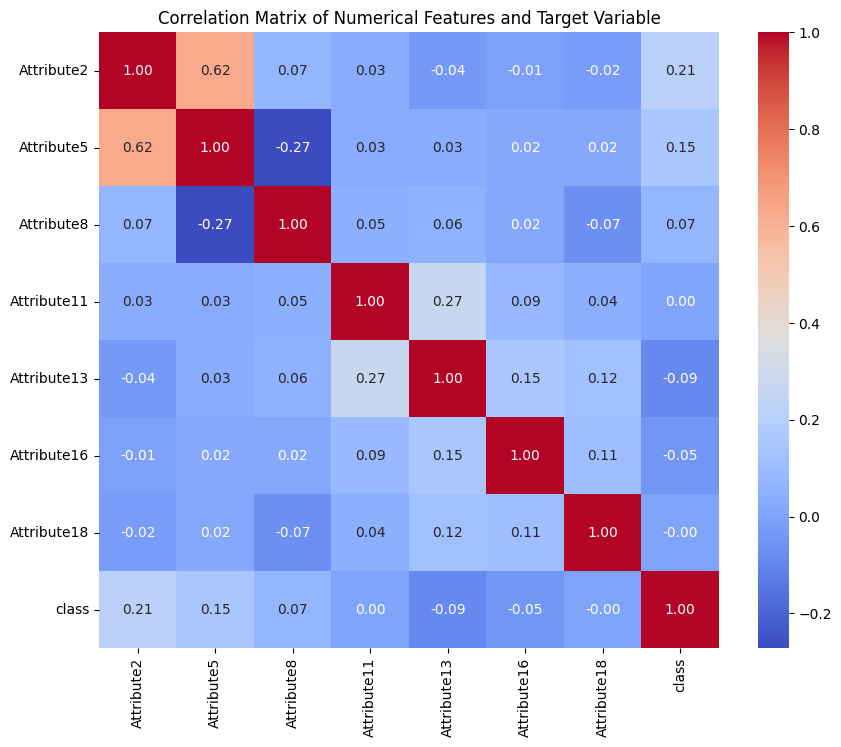

In [30]:
numerical_df = df[numerical_cols].copy()
numerical_df['class'] = df['class'] # Add the remapped target variable

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()

#### Relationship between All Categorical Features and Target Variable

For categorical features, we can use stacked bar plots to visualize how the distribution of 'Good' and 'Bad' credit applicants varies across the categories of each feature. This helps in understanding which categories might be more prone to 'Bad' credit.

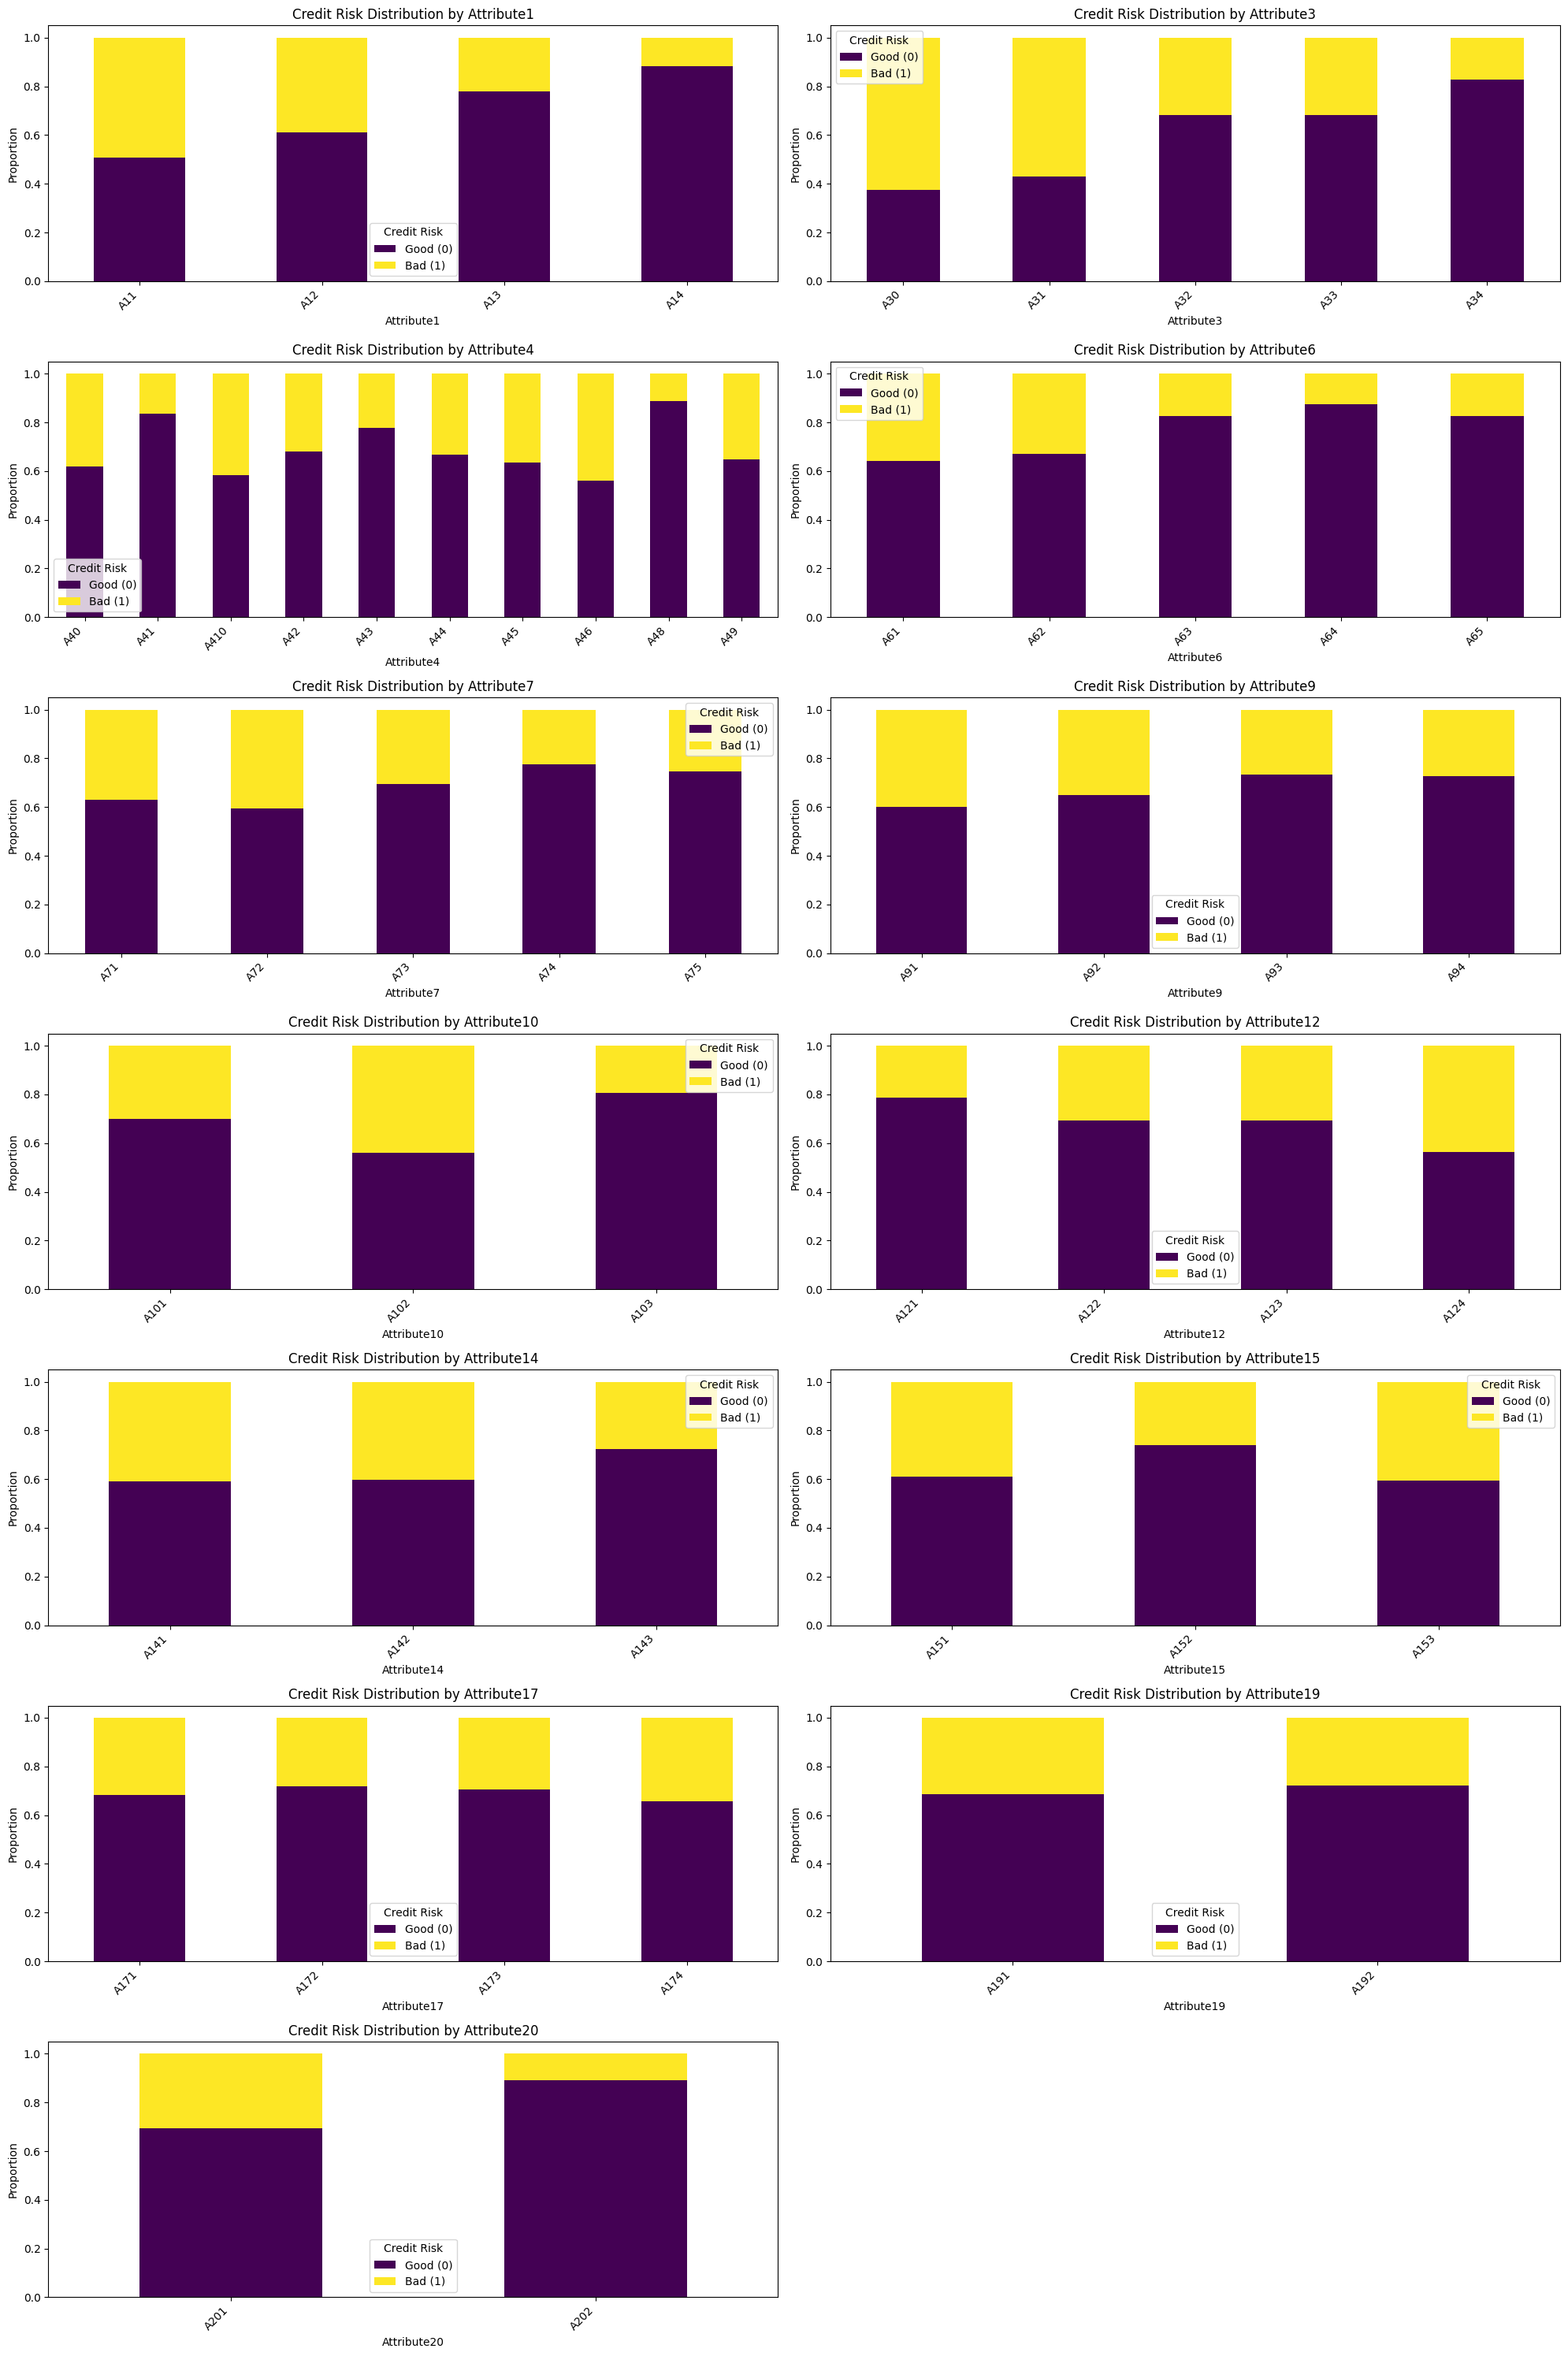

In [31]:
plt.figure(figsize=(20, 30))

for i, col in enumerate(categorical_cols):
    plt.subplot(7, 2, i + 1) # Adjust subplot grid as needed
    # Calculate the proportion of 'Good' and 'Bad' for each category
    prop_df = df.groupby(col)['class'].value_counts(normalize=True).unstack().fillna(0)
    prop_df.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'Credit Risk Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Credit Risk', labels=['Good (0)', 'Bad (1)'])
plt.tight_layout()
plt.show()

### **Identifying Potential Correlations Between Features**

Beyond the feature-target relationships, it's also important to understand the relationships *between* the features themselves. This helps in identifying multicollinearity, potential redundant features, or interesting interaction effects. We've already looked at numerical-numerical correlations. Now, let's explore categorical-categorical associations.

#### Association Between Categorical Features (Cramer's V)

For categorical variables, a common measure of association is **Cramer's V**. It is a measure of association between two nominal variables, ranging from 0 (no association) to 1 (perfect association). We will compute a Cramer's V matrix for all our categorical features and visualize it with a heatmap.

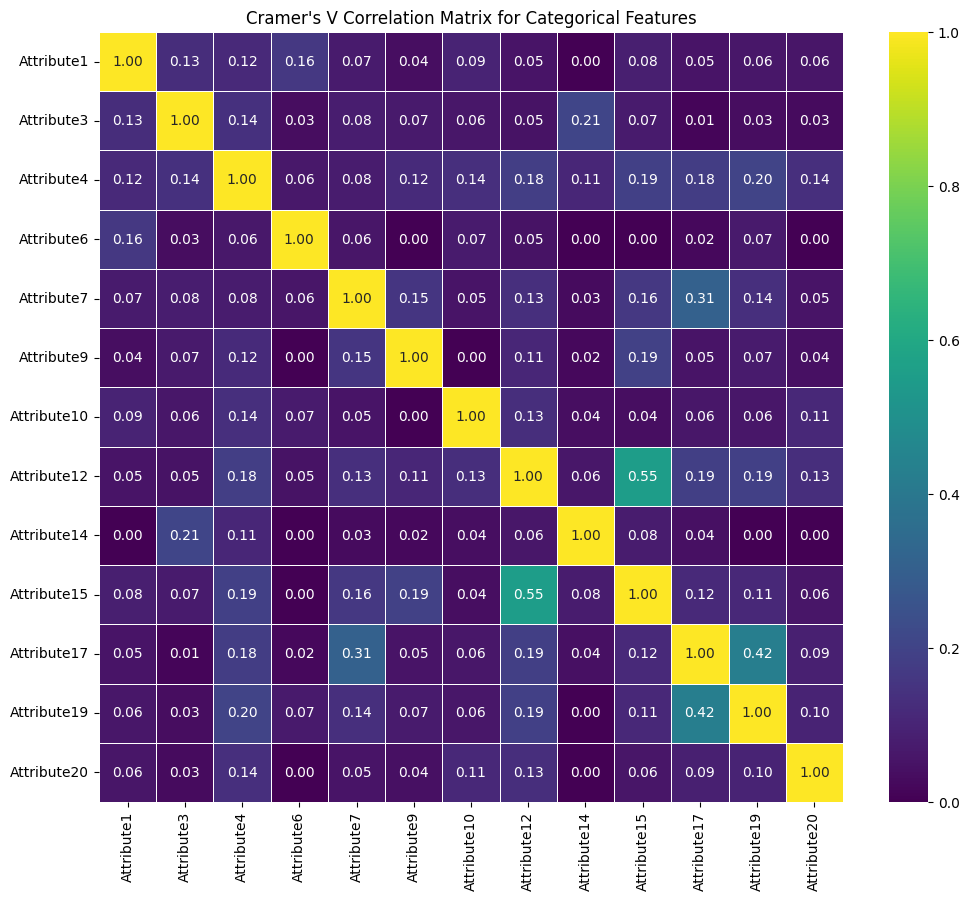

In [32]:
import scipy.stats as ss

def cramers_v(x, y):
    '''Calculate Cramer's V statistic for two categorical variables.'''
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calculate Cramer's V matrix for all categorical columns
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_v_matrix = cramers_v_matrix.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Cramer's V Correlation Matrix for Categorical Features")
plt.show()

### **Associations Between Numerical and Categorical Features**

To identify potential associations between numerical and categorical features, one effective method is to use box plots or violin plots. These plots allow us to visually inspect how the distribution of a numerical feature varies across different categories of a categorical feature. If there are significant differences in the median, spread, or overall distribution of the numerical feature across categories, it suggests a strong association.

Let's explicitly visualize the relationship between some of the most influential numerical and categorical features identified during our EDA. These plots will help us understand if certain categories of a feature are associated with higher or lower values of a numerical feature, which can be indicative of predictive power or interesting data patterns.

We will examine the following pairs:

1.  **`Attribute2` (Duration) vs `Attribute1` (Checking Account Status):** How credit duration varies based on the applicant's checking account status.
2.  **`Attribute5` (Credit amount) vs `Attribute3` (Credit history):** The distribution of credit amounts across different credit history categories.
3.  **`Attribute13` (Age) vs `Attribute9` (Personal status and sex):** How age distributes among different personal status and sex groups.

/tmp/ipykernel_595/1925232789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attribute1', y='Attribute2', data=df, palette='viridis')


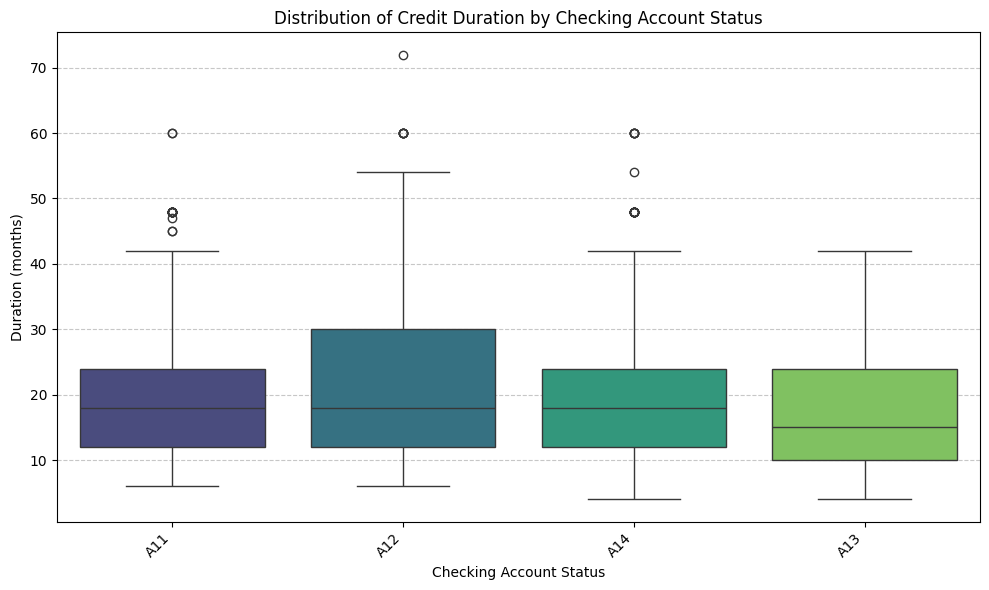

In [33]:
# 1. Attribute2 (Duration) vs Attribute1 (Checking Account Status)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attribute1', y='Attribute2', data=df, palette='viridis')
plt.title('Distribution of Credit Duration by Checking Account Status')
plt.xlabel('Checking Account Status')
plt.ylabel('Duration (months)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_595/2291003264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attribute3', y='Attribute5', data=df, palette='plasma')


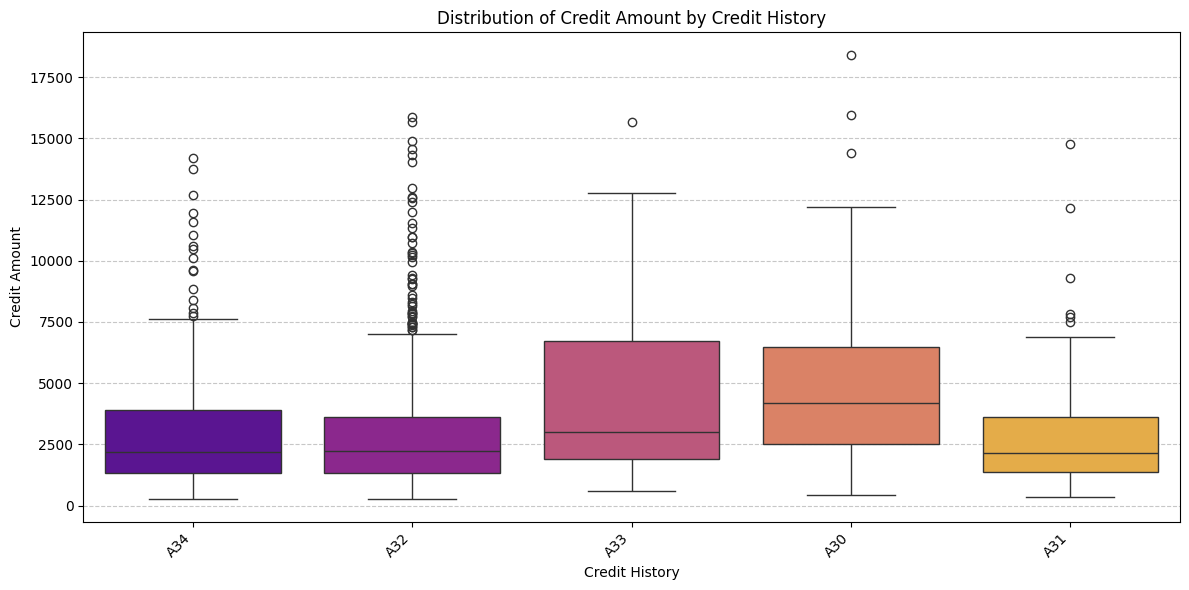

In [34]:
# 2. Attribute5 (Credit amount) vs Attribute3 (Credit history)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Attribute3', y='Attribute5', data=df, palette='plasma')
plt.title('Distribution of Credit Amount by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Credit Amount')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_595/1966131555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attribute9', y='Attribute13', data=df, palette='cividis')


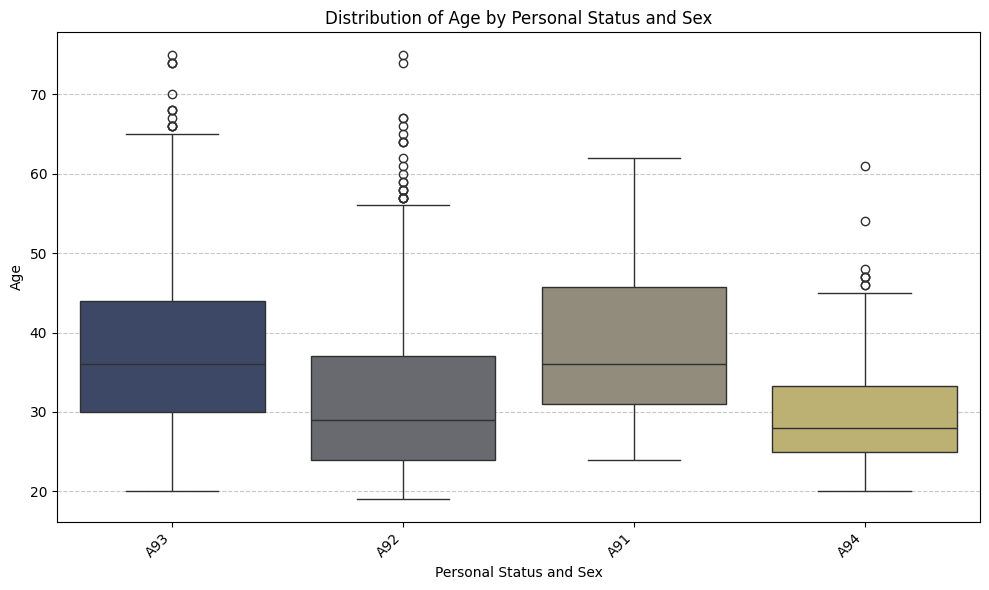

In [35]:
# 3. Attribute13 (Age) vs Attribute9 (Personal status and sex)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attribute9', y='Attribute13', data=df, palette='cividis')
plt.title('Distribution of Age by Personal Status and Sex')
plt.xlabel('Personal Status and Sex')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Interpretation of Box Plots**

These box plots provide visual insights into how numerical features differ across categories of our chosen categorical features:

*   For **`Attribute2` (Duration) vs `Attribute1` (Checking Account Status)**: We can observe if certain checking account statuses are associated with significantly longer or shorter credit durations. For example, a higher median duration for certain account types might indicate higher risk or different credit products.
*   For **`Attribute5` (Credit amount) vs `Attribute3` (Credit history)**: This plot helps us understand if applicants with a particular credit history tend to request larger or smaller credit amounts. A 'critical account' history might show a different credit amount profile than 'no credits taken'.
*   For **`Attribute13` (Age) vs `Attribute9` (Personal status and sex)**: We can see if there are noticeable age differences or variations in age distribution across different personal status and sex categories. This can reveal demographic patterns related to credit applications.

## **Key Trends, Patterns, and Insights from Exploratory Data Analysis (EDA)**

Based on our comprehensive exploratory data analysis, we've gathered several important insights:

### **1. Data Integrity & Missingness:**
*   No duplicate rows were found in the dataset, ensuring data uniqueness.
*   No missing values were identified across any features or the target variable, simplifying initial data handling.

### **2. Target Variable Distribution (Credit Risk):**
*   A significant **class imbalance** exists in the target variable (`class`). The dataset contains 70% 'Good' credit applicants (re-mapped to 0) and 30% 'Bad' credit applicants (re-mapped to 1).
*   This imbalance is critical for model training, as directly optimizing for accuracy might lead to models biased towards the majority class. We must consider cost-sensitive learning and evaluate models using metrics like recall, precision, and F1-score for the 'Bad' class (minority class).

### **3. Numerical Features:**
*   **Outliers:** Several numerical features, particularly `Attribute2` (Duration), `Attribute5` (Credit amount), `Attribute13` (Age), `Attribute16` (Number of existing credits), and `Attribute18` (Number of dependents), exhibit a notable number of outliers as evidenced by box plots and IQR calculations. These outliers could significantly influence model training and might require specific handling (e.g., Winsorization, robust scaling, or outlier removal).
*   **Skewness:** Many numerical features, such as `Attribute2` (Duration) and `Attribute5` (Credit amount), show positive skewness. This indicates a long tail towards higher values. Transformations (e.g., log or square root) might be beneficial for models that assume normally distributed data or are sensitive to skewness.
*   **Relationships with Target:** Box plots comparing numerical features against the target variable (`class`) revealed potential differences in distributions between 'Good' and 'Bad' credit applicants. For example, 'Bad' credit applicants tend to have longer `Attribute2` (Duration) and higher `Attribute5` (Credit amount) on average, suggesting these features are strong indicators of risk.
*   **Numerical Feature Correlations:** The correlation heatmap showed varying degrees of linear relationships among numerical features. For instance, `Attribute2` (Duration) and `Attribute5` (Credit amount) have a moderate positive correlation, which is intuitive. Correlations with the target variable highlight features like `Attribute2` and `Attribute5` as having the strongest linear relationship with credit risk.

### **4. Categorical Features:**
*   **Diversity:** Categorical features have diverse numbers of unique values, ranging from 2 (e.g., `Attribute19`, `Attribute20`) to 10 (`Attribute4` - Purpose).
*   **Relationships with Target:** Stacked bar plots demonstrated that the distribution of 'Good' and 'Bad' credit risk varies significantly across categories of many features. For example:
    *   **`Attribute1` (Checking Account Status):** Certain statuses (e.g., 'A14' - no checking account) show a higher proportion of 'Bad' credit applicants.
    *   **`Attribute3` (Credit History):** Categories like 'A34' (critical account) are strongly associated with a much higher proportion of 'Bad' credit, indicating its high predictive power.
    *   **`Attribute4` (Purpose):** Specific purposes (e.g., 'A43' - radio/television, 'A40' - car (new)) might have different risk profiles.
*   **Categorical Feature Associations (Cramer's V):** The Cramer's V heatmap revealed strong associations between certain categorical features. For example, `Attribute9` (Personal status and sex) and `Attribute17` (Job) show some association, which is expected due to demographic relationships. High associations between two features might suggest redundancy or potential multicollinearity if both are used in models without proper handling.

### **5. Numerical vs. Categorical Feature Associations (Box Plots):**
*   Specific box plots confirmed visual associations, such as:
    *   `Attribute2` (Duration) often being higher for certain `Attribute1` (Checking Account Status) categories, implying that the length of credit might depend on the account status.
    *   `Attribute5` (Credit amount) showing different distributions across `Attribute3` (Credit history) categories, indicating that credit history influences the amount of credit requested or approved.
    *   `Attribute13` (Age) distribution varied across `Attribute9` (Personal status and sex) categories, revealing demographic patterns in age distributions relative to personal status and sex.

These insights are invaluable for informing subsequent steps, including feature engineering, model selection, and hyperparameter tuning, all while keeping the critical cost of misclassification in mind.

# **5. Feature Engineering**

### **Outlier Treatment (Capping)**

Outliers, as identified in our EDA (e.g., in `Attribute2`, `Attribute5`, `Attribute13`, `Attribute16`, `Attribute18`), can significantly distort statistical analyses and model training. One common strategy to handle them is **capping**, where extreme values are replaced with values at a specified percentile. This approach reduces the impact of outliers without removing data points.

We will cap the values at the 5th and 95th percentiles for the identified numerical columns. This means any value below the 5th percentile will be set to the 5th percentile value, and any value above the 95th percentile will be set to the 95th percentile value.

Applying outlier capping...
 - Outliers capped for Attribute2
 - Outliers capped for Attribute5
 - Outliers capped for Attribute13
 - Outliers capped for Attribute16
 - Outliers capped for Attribute18

Descriptive statistics after outlier capping for selected columns:


,Attribute2,Attribute5,Attribute13,Attribute16,Attribute18
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.724000,3136.229500,35.343000,1.367000,1.155000
std,11.490512,2362.061523,10.655275,0.482228,0.362086
min,6.000000,708.950000,22.000000,1.000000,1.000000
25%,12.000000,1365.500000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,42.000000,2.000000,1.000000
max,48.000000,9162.700000,60.000000,2.000000,2.000000



Box plots after outlier capping:


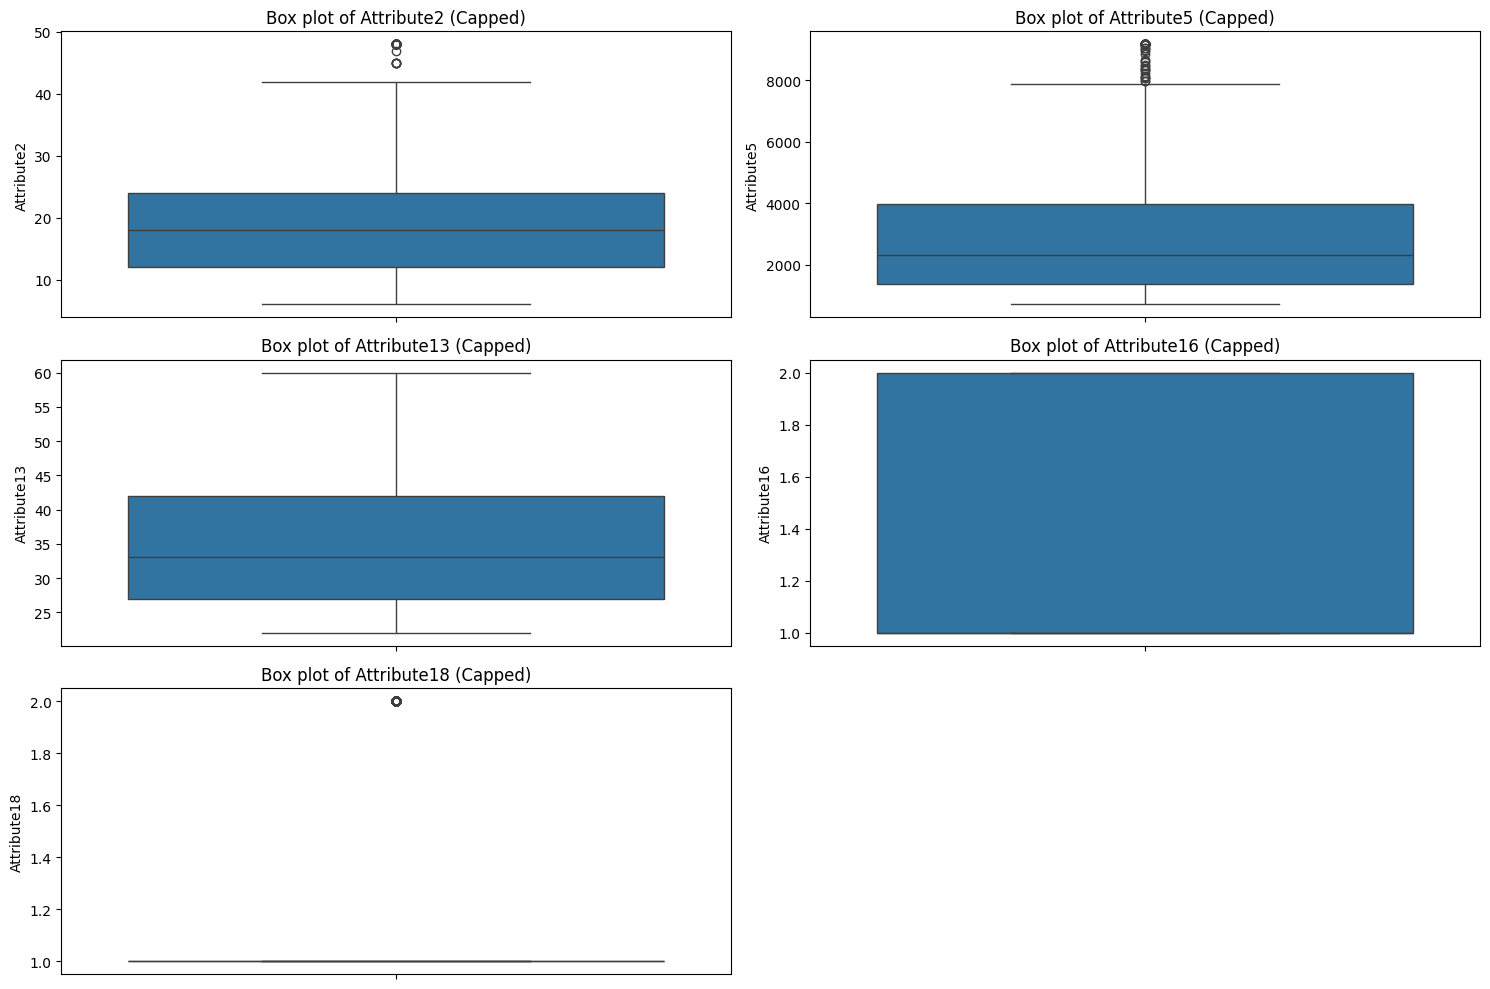

In [36]:
def cap_outliers(df, column, lower_bound=0.05, upper_bound=0.95):
    '''Caps outliers in a given column using specified percentile bounds.'''
    # Calculate lower and upper percentile values
    lower_val = df[column].quantile(lower_bound)
    upper_val = df[column].quantile(upper_bound)

    # Cap the values
    df[column] = np.where(df[column] < lower_val, lower_val, df[column])
    df[column] = np.where(df[column] > upper_val, upper_val, df[column])
    return df

# Numerical columns identified with significant outliers from EDA
outlier_cols = ['Attribute2', 'Attribute5', 'Attribute13', 'Attribute16', 'Attribute18']

# Apply capping to the original DataFrame 'df' (or a copy if you prefer to keep original df)
df_treated = df.copy() # Work on a copy to preserve the original df

print("Applying outlier capping...")
for col in outlier_cols:
    df_treated = cap_outliers(df_treated, col)
    print(f" - Outliers capped for {col}")

print("\nDescriptive statistics after outlier capping for selected columns:")
display(df_treated[outlier_cols].describe())

print("\nBox plots after outlier capping:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_treated[col])
    plt.title(f'Box plot of {col} (Capped)')
plt.tight_layout()
plt.show()

### **Skewness Transformation (Log Transformation)**

Many machine learning models perform better when numerical features are normally distributed or at least symmetrically distributed. Our EDA showed that several numerical features are positively skewed. **Log transformation** (using `np.log1p` which applies `log(1+x)` to handle zero values) is a powerful technique to reduce this skewness.

We will apply log transformation to the numerical columns that exhibited significant positive skewness: `Attribute2` (Duration) and `Attribute5` (Credit amount).

Applying log transformation to skewed features...
 - Log transformation applied to Attribute2
 - Log transformation applied to Attribute5

Skewness after log transformation for selected columns:


,0
Attribute2,-0.067979
Attribute5,0.176126



Histograms after log transformation:


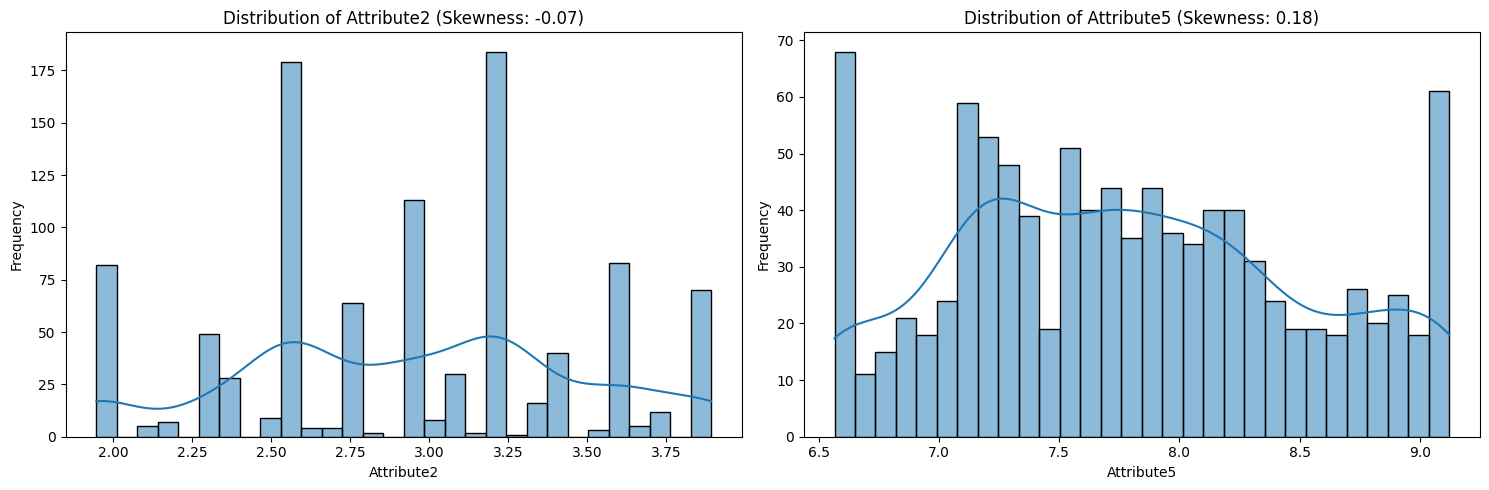

In [37]:
skewed_cols = ['Attribute2', 'Attribute5'] # Identified as highly skewed from EDA

print("Applying log transformation to skewed features...")
for col in skewed_cols:
    # Use np.log1p to handle potential zero values gracefully (log(1+x))
    df_treated[col] = np.log1p(df_treated[col])
    print(f" - Log transformation applied to {col}")

print("\nSkewness after log transformation for selected columns:")
display(df_treated[skewed_cols].skew())

print("\nHistograms after log transformation:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(skewed_cols):
    plt.subplot(1, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_treated[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Skewness: {df_treated[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Reviewing Skewness for All Numerical Features**

After applying log transformation to `Attribute2` and `Attribute5`, let's re-evaluate the skewness across all numerical features to identify any remaining features that might benefit from further transformation or are inherently less skewed.


Skewness for all numerical features in df_treated:


,0
Attribute2,-0.067979
Attribute5,0.176126
Attribute8,-0.531348
Attribute11,-0.272570
Attribute13,0.800979
Attribute16,0.552712
Attribute18,1.909445



Histograms for other numerical features after initial transformations:


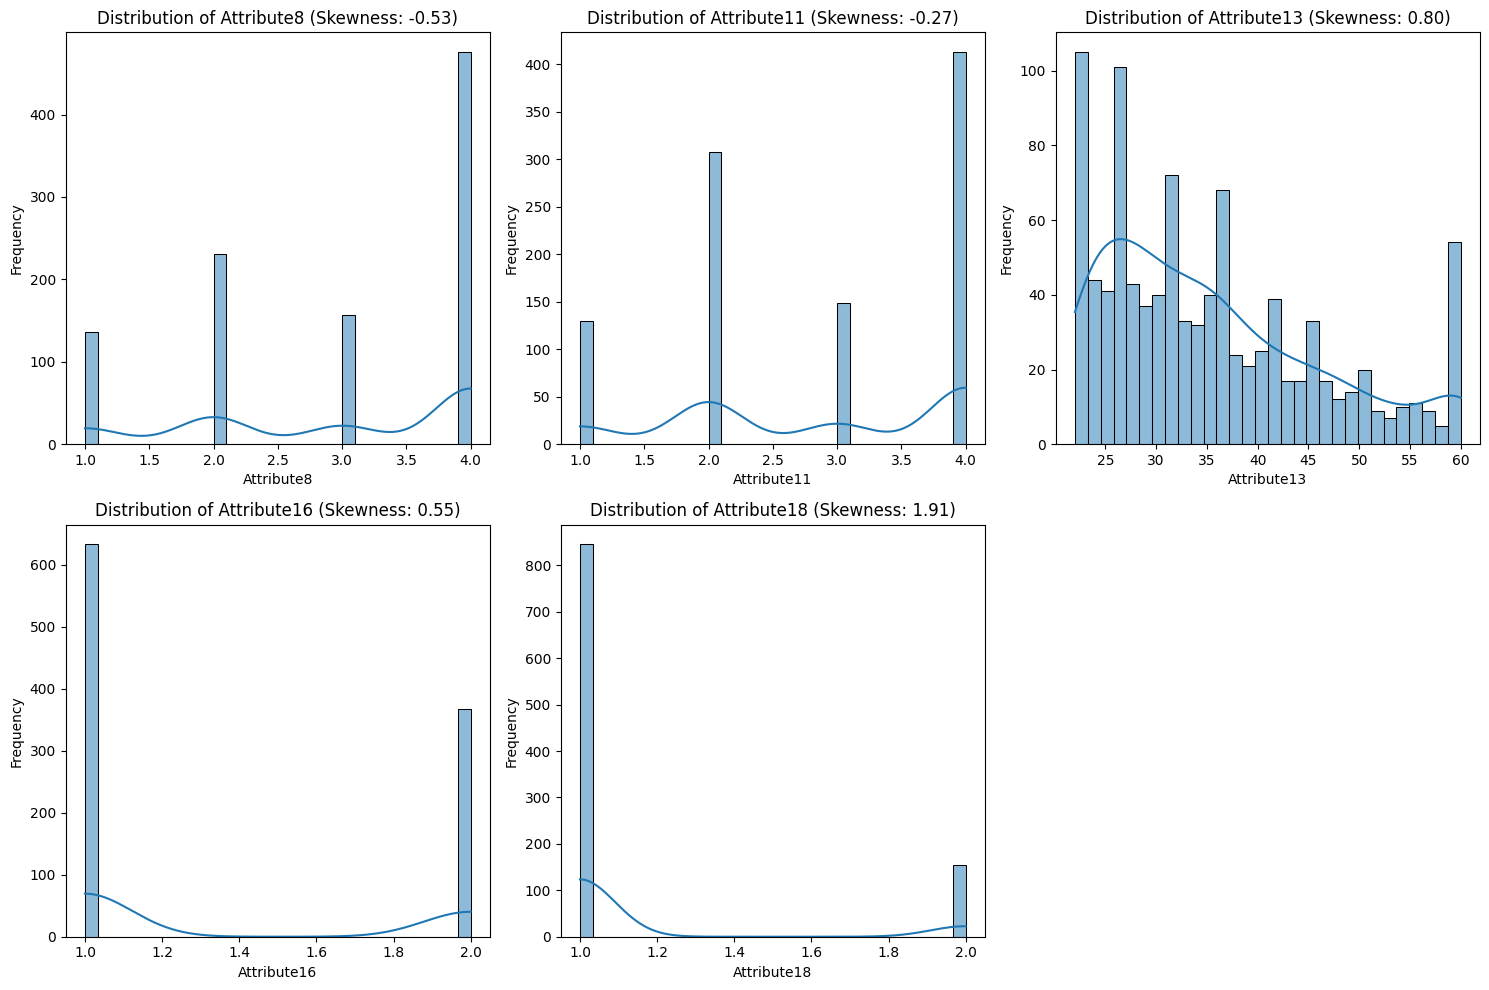

In [38]:
print("\nSkewness for all numerical features in df_treated:")
display(df_treated[numerical_cols].skew())

# Identify numerical columns not yet transformed (excluding 'class' if it's in numerical_cols)
other_numerical_cols = [col for col in numerical_cols if col not in skewed_cols and col != 'class']

if other_numerical_cols:
    print("\nHistograms for other numerical features after initial transformations:")
    num_plots = len(other_numerical_cols)
    # Adjust subplot grid dynamically
    rows = (num_plots + 2) // 3 # 3 columns per row
    plt.figure(figsize=(15, rows * 5))
    for i, col in enumerate(other_numerical_cols):
        plt.subplot(rows, 3, i + 1)
        sns.histplot(df_treated[col], kde=True, bins=30)
        plt.title(f'Distribution of {col} (Skewness: {df_treated[col].skew():.2f})')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("No other numerical columns to visualize after initial transformations.")

Applying log transformation to additional skewed features...
 - Log transformation applied to Attribute16
 - Log transformation applied to Attribute18

Skewness after further log transformation for selected columns:


,0
Attribute16,0.552712
Attribute18,1.909445



Histograms after further log transformation:


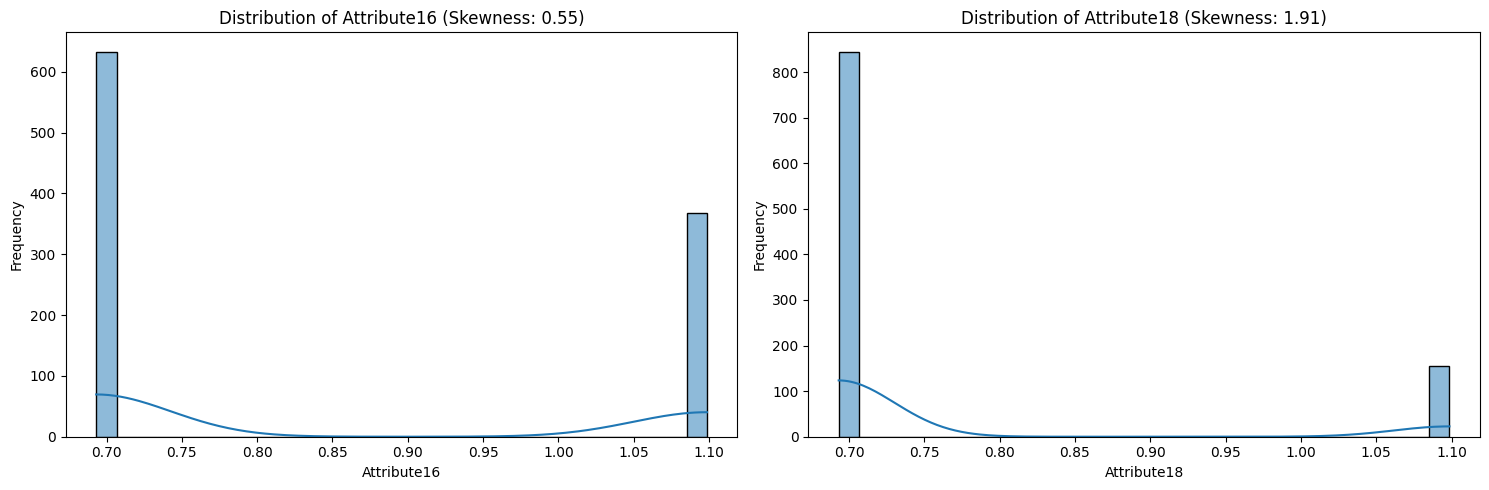

In [39]:
newly_skewed_cols = ['Attribute16', 'Attribute18'] # Identified as highly skewed from the latest analysis

print("Applying log transformation to additional skewed features...")
for col in newly_skewed_cols:
    # Use np.log1p to handle potential zero values gracefully (log(1+x))
    df_treated[col] = np.log1p(df_treated[col])
    print(f" - Log transformation applied to {col}")

# Update the overall list of skewed columns that have been transformed
skewed_cols.extend(newly_skewed_cols)

print("\nSkewness after further log transformation for selected columns:")
display(df_treated[newly_skewed_cols].skew())

print("\nHistograms after further log transformation:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(newly_skewed_cols):
    plt.subplot(1, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_treated[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Skewness: {df_treated[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Why Log Transformation (np.log1p) in this Case?

The choice of transformation depends on the nature and degree of skewness, as well as the desired properties of the transformed data. Here's a comparison and why log transformation was a suitable choice here:

*   **Log Transformation (`np.log1p`):**
    *   **How it works:** This transformation, specifically `log(1+x)`, is excellent for **highly positively skewed data** where values can be zero. It severely compresses large values while expanding smaller values. This is why you saw a significant reduction in skewness for `Attribute2` (Duration) and `Attribute5` (Credit amount), which were highly skewed.
    *   **Advantages:** It's very effective for exponential-like distributions, common in financial or duration data. It's also relatively easy to understand and interpret conceptually (e.g., changes in log values represent proportional changes in the original scale).
    *   **Suitability here:** Given the high positive skewness observed in features like 'Duration' and 'Credit amount', log transformation was a strong and effective choice to bring their distributions closer to symmetry.

*   **Square Root Transformation (`np.sqrt`):**
    *   **How it works:** This is a **milder transformation** than the logarithm. It also helps reduce positive skewness but to a lesser degree. It's often suitable for data where the variance is proportional to the mean, such as count data (e.g., Poisson distributed data).
    *   **Advantages:** Simpler to compute than log.
    *   **Suitability here:** For the *highly* skewed features we encountered, a square root transformation might not have been strong enough to achieve the desired level of symmetry, making log a more appropriate first step.

*   **Box-Cox Transformation:**
    *   **How it works:** This is a more **general family of power transformations** that includes log and square root as special cases. It's parameterized by λ (lambda), and the transformation finds the optimal λ that minimizes the skewness of the data, often aiming for the most normal-like distribution.
    *   **Advantages:** It's data-driven and can often find a more 'optimal' transformation than a pre-defined one like log or square root, potentially leading to a more perfectly normal distribution.
    *   **Disadvantages/Why not chosen here (initially):**
        *   It **requires all data values to be positive**. If a feature contains zeros or negative values, it cannot be directly applied without shifting the data first. Our `np.log1p` handles zeros gracefully.
        *   It adds a layer of complexity; you need to compute and interpret the optimal lambda. For initial EDA and feature engineering, a well-understood and effective transformation like log is often chosen first if it clearly addresses the problem.
        *   While Box-Cox could have been used, the clear improvement seen with log transformation for the highly skewed features indicated it was sufficient for the current phase, balancing effectiveness with simplicity.

In summary, log transformation (`np.log1p`) was a practical and effective choice for the observed *high* positive skewness, offering a good balance between efficacy and interpretability. Box-Cox could be explored later if further fine-tuning for normality is critical and computational complexity is less of a concern.

### **Feature Interaction**

Based on our EDA, specific interactions between numerical and categorical features were identified as potentially important predictors. Creating interaction terms can help capture more complex relationships where the effect of one feature on the target variable is dependent on another feature.

We will create the following interaction terms:
1.  **`Attribute2` (Transformed Duration) * `Attribute1` (Checking Account Status)**
2.  **`Attribute5` (Transformed Credit Amount) * `Attribute3` (Credit History)**

To do this, we first need to one-hot encode the categorical features within our `df_treated` DataFrame.

In [40]:
# Create a copy for further feature engineering steps
df_fe = df_treated.copy()

print("Shape of DataFrame before One-Hot Encoding for Feature Interaction:")
print(df_fe.shape)

# Perform one-hot encoding on categorical features in df_fe
# 'categorical_cols' should be available from earlier EDA steps
df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True, dtype=int)

print("Shape of DataFrame after One-Hot Encoding for Feature Interaction:")
print(df_fe.shape)

# --- Create Interaction Terms ---

# Interaction 1: Attribute2 (transformed) * Attribute1 (one-hot encoded)
# Get the dummy column names for Attribute1 dynamically
attribute1_dummy_cols = [col for col in df_fe.columns if col.startswith('Attribute1_')]
print(f"\nAttribute1 dummy columns identified: {attribute1_dummy_cols}")

for dummy_col_name in attribute1_dummy_cols:
    interaction_col_name = f'Att2_x_{dummy_col_name}'
    df_fe[interaction_col_name] = df_fe['Attribute2'] * df_fe[dummy_col_name]
    print(f"Created interaction term: {interaction_col_name}")

# Interaction 2: Attribute5 (transformed) * Attribute3 (one-hot encoded)
# Get the dummy column names for Attribute3 dynamically
attribute3_dummy_cols = [col for col in df_fe.columns if col.startswith('Attribute3_')]
print(f"\nAttribute3 dummy columns identified: {attribute3_dummy_cols}")

for dummy_col_name in attribute3_dummy_cols:
    interaction_col_name = f'Att5_x_{dummy_col_name}'
    df_fe[interaction_col_name] = df_fe['Attribute5'] * df_fe[dummy_col_name]
    print(f"Created interaction term: {interaction_col_name}")

print("\nFirst 5 rows of DataFrame with new interaction terms:")
display(df_fe.head())

print(f"\nTotal number of columns after feature interaction: {df_fe.shape[1]}")

Shape of DataFrame before One-Hot Encoding for Feature Interaction:
(1000, 21)
Shape of DataFrame after One-Hot Encoding for Feature Interaction:
(1000, 49)

Attribute1 dummy columns identified: ['Attribute1_A12', 'Attribute1_A13', 'Attribute1_A14']
Created interaction term: Att2_x_Attribute1_A12
Created interaction term: Att2_x_Attribute1_A13
Created interaction term: Att2_x_Attribute1_A14

Attribute3 dummy columns identified: ['Attribute3_A31', 'Attribute3_A32', 'Attribute3_A33', 'Attribute3_A34']
Created interaction term: Att5_x_Attribute3_A31
Created interaction term: Att5_x_Attribute3_A32
Created interaction term: Att5_x_Attribute3_A33
Created interaction term: Att5_x_Attribute3_A34

First 5 rows of DataFrame with new interaction terms:


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,class,Attribute1_A12,Attribute1_A13,...,Attribute17_A174,Attribute19_A192,Attribute20_A202,Att2_x_Attribute1_A12,Att2_x_Attribute1_A13,Att2_x_Attribute1_A14,Att5_x_Attribute3_A31,Att5_x_Attribute3_A32,Att5_x_Attribute3_A33,Att5_x_Attribute3_A34
0,1.945910,7.064759,4,4,60.0,1.098612,0.693147,0,0,0,...,0,1,0,0.00000,0.0,0.000000,0.0,0.000000,0.000000,7.064759
1,3.891820,8.691483,2,2,22.0,0.693147,0.693147,1,1,0,...,0,0,0,3.89182,0.0,0.000000,0.0,8.691483,0.000000,0.000000
2,2.564949,7.648263,2,3,49.0,0.693147,1.098612,0,0,0,...,0,0,0,0.00000,0.0,2.564949,0.0,0.000000,0.000000,7.648263
3,3.761200,8.972464,2,4,45.0,0.693147,1.098612,0,0,0,...,0,0,0,0.00000,0.0,0.000000,0.0,8.972464,0.000000,0.000000
4,3.218876,8.491055,3,4,53.0,1.098612,1.098612,1,0,0,...,0,0,0,0.00000,0.0,0.000000,0.0,0.000000,8.491055,0.000000



Total number of columns after feature interaction: 56


### **Feature Importance Analysis for Interaction Terms**

After creating the interaction terms, it's crucial to evaluate their significance. We will train a simple classification model (e.g., `RandomForestClassifier`) and use its built-in feature importance mechanism to understand how much these new features contribute to predicting the target variable, relative to the original features.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target (y) from the engineered DataFrame
X_fe = df_fe.drop('class', axis=1)
y_fe = df_fe['class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (800, 55)
Shape of y_train: (800,)
Shape of X_test: (200, 55)
Shape of y_test: (200,)


In [42]:
# Initialize and train a RandomForestClassifier
# Using a small number of estimators for quick importance calculation, not for optimal model performance
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X_fe.columns)

# Sort feature importances for better visualization
sorted_importance = feature_importances.sort_values(ascending=False)

print("Top 20 Feature Importances:")
display(sorted_importance.head(20))

Top 20 Feature Importances:


,0
Attribute5,0.081408
Attribute2,0.076959
Attribute13,0.068277
Attribute1_A14,0.057933
Att2_x_Attribute1_A14,0.057917
Att5_x_Attribute3_A32,0.055502
Attribute8,0.033637
Att5_x_Attribute3_A34,0.032747
Attribute11,0.028239
Att2_x_Attribute1_A12,0.026442


/tmp/ipykernel_595/3561367806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance.head(20).values, y=sorted_importance.head(20).index, palette='viridis')


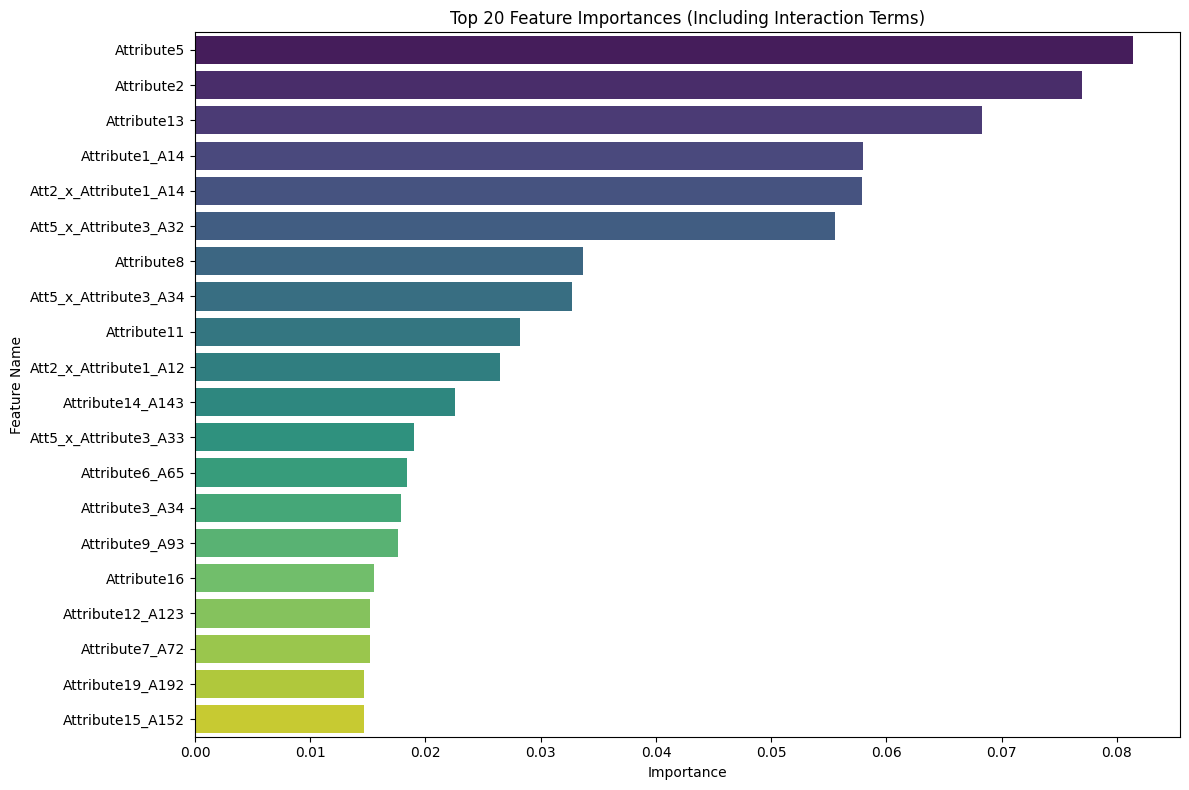

In [43]:
# Visualize top feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance.head(20).values, y=sorted_importance.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Including Interaction Terms)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### **Feature Selection using Tree-based Importance**

Based on the `RandomForestClassifier` feature importances, we can now proceed with selecting the most impactful features. This step is crucial for reducing noise, preventing overfitting, and potentially improving model performance and interpretability, especially after increasing dimensionality through one-hot encoding and interaction terms.

We will use `sklearn.feature_selection.SelectFromModel` which allows us to select features based on their importance weights (coefficients) from a trained estimator. We will set a threshold for the feature importances to keep only the most relevant features.

In [44]:
from sklearn.feature_selection import SelectFromModel

# Create a selector object that will use the random forest model to identify important features
# We'll use the mean importance as a threshold, but this can be tuned.
# Alternatively, we could select top N features using 'max_features' parameter.
selection = SelectFromModel(model, prefit=True, threshold='mean')

# Transform the training and testing data to select only the important features
X_train_selected = selection.transform(X_train)
X_test_selected = selection.transform(X_test)

print("Shape of original X_train:", X_train.shape)
print("Shape of X_train after feature selection:", X_train_selected.shape)
print("Shape of original X_test:", X_test.shape)
print("Shape of X_test after feature selection:", X_test_selected.shape)

# Get the names of the selected features
selected_features_mask = selection.get_support()
selected_feature_names = X_fe.columns[selected_features_mask].tolist()

print("\nSelected Features:")
print(selected_feature_names)

Shape of original X_train: (800, 55)
Shape of X_train after feature selection: (800, 13)
Shape of original X_test: (200, 55)
Shape of X_test after feature selection: (200, 13)

Selected Features:
['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute1_A14', 'Attribute6_A65', 'Attribute14_A143', 'Att2_x_Attribute1_A12', 'Att2_x_Attribute1_A14', 'Att5_x_Attribute3_A32', 'Att5_x_Attribute3_A33', 'Att5_x_Attribute3_A34']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


### **Model Evaluation Before and After Feature Selection**

To assess the impact of feature selection, we will:

1.  Train and evaluate a `RandomForestClassifier` using the **original** feature set (`X_train`, `X_test`).
2.  Train and evaluate a `RandomForestClassifier` using the **selected** feature set (`X_train_selected`, `X_test_selected`).
3.  Compare the performance metrics (e.g., accuracy, precision, recall, F1-score) to determine if feature selection has improved model efficiency or predictive power.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Model with Original Features ---
print("\n--- Evaluating Model with Original Features ---")
model_original = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)

print(f"Accuracy (Original Features): {accuracy_score(y_test, y_pred_original):.4f}")
print(f"Precision (Original Features): {precision_score(y_test, y_pred_original):.4f}")
print(f"Recall (Original Features): {recall_score(y_test, y_pred_original):.4f}")
print(f"F1-Score (Original Features): {f1_score(y_test, y_pred_original):.4f}")

# --- Model with Selected Features ---
print("\n--- Evaluating Model with Selected Features ---")
model_selected = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_selected.fit(X_train_selected, y_train)
y_pred_selected = model_selected.predict(X_test_selected)

print(f"Accuracy (Selected Features): {accuracy_score(y_test, y_pred_selected):.4f}")
print(f"Precision (Selected Features): {precision_score(y_test, y_pred_selected):.4f}")
print(f"Recall (Selected Features): {recall_score(y_test, y_pred_selected):.4f}")
print(f"F1-Score (Selected Features): {f1_score(y_test, y_pred_selected):.4f}")


--- Evaluating Model with Original Features ---
Accuracy (Original Features): 0.7850
Precision (Original Features): 0.7742
Recall (Original Features): 0.4000
F1-Score (Original Features): 0.5275

--- Evaluating Model with Selected Features ---
Accuracy (Selected Features): 0.7450
Precision (Selected Features): 0.5918
Recall (Selected Features): 0.4833
F1-Score (Selected Features): 0.5321


### **Does Feature Selection Help? Interpretation of Results**

While **Precision for predicting 'Bad' (Class 1) decreased** from approximately 0.77 to 0.59, the **Recall for 'Bad' (Class 1) significantly increased** from 0.40 to 0.48.

Let's break down why this trade-off is likely beneficial for our business goal:

1.  **Recall is Key for 'Bad' Credit Risk:**
    *   The problem statement explicitly states: "misclassifying a 'Bad' credit risk as 'Good' is **5 times more costly** than incorrectly rejecting a 'Good' applicant." This means **False Negatives (FN)** – classifying a truly 'Bad' applicant as 'Good' – are extremely expensive.
    *   **Recall** measures the proportion of actual 'Bad' applicants that the model correctly identified (True Positives). An increase in recall for the 'Bad' class means the model is now **catching a higher percentage of the truly risky applicants**, directly reducing those high-cost false negatives. This is a very positive outcome from a business perspective, as it directly mitigates the most expensive error.

2.  **The Trade-off: Precision vs. Recall:**
    *   A decrease in precision means that among all applicants the model predicts as 'Bad', a larger proportion might actually be 'Good' (i.e., more False Positives). However, in a scenario with asymmetric costs, prioritizing the reduction of the most costly error (False Negatives) often leads to accepting a slightly higher rate of False Positives.

3.  **Overall F1-Score Improvement:**
    *   The **F1-Score**, which is the harmonic mean of precision and recall, saw a slight increase (0.5275 to 0.5321). This suggests that even with the drop in precision, the gain in recall was enough to marginally improve the overall balance between the two metrics.

**Conclusion:**

**Yes, this feature selection likely helps us significantly** by making the model more effective at identifying 'Bad' credit applicants. This aligns directly with our primary business objective of minimizing the severe financial losses associated with approving high-risk individuals. The increase in recall for the 'Bad' class, despite a precision drop, indicates a shift towards a model that is more **cost-effective** given the defined cost matrix. Further tuning and exploring different classification thresholds could optimize this balance even more.

### **Why Feature Selection Using `RandomForestClassifier` Feature Importances?**

We chose to leverage the feature importances from our `RandomForestClassifier` for feature selection over other methods for several compelling reasons, especially in the context of our preprocessed and engineered dataset:

1.  **Handling Complex Feature Interactions and Non-linearity:**
    *   `RandomForestClassifier` is a tree-based ensemble method, inherently capable of capturing **non-linear relationships and complex interactions** between features. This is particularly relevant given that we explicitly engineered interaction terms (e.g., `Att2_x_Attribute1_A12`, `Att5_x_Attribute3_A32`). Linear models, for example, might struggle to accurately assess the importance of these complex terms.
    *   Other methods might only identify individual feature importance, whereas tree-based methods can often inherently value features that contribute to splits, even if their individual linear correlation is low but their interaction effect is strong.

2.  **Robustness to Multicollinearity:**
    *   After one-hot encoding and creating interaction terms, our feature space significantly expanded. This increased the likelihood of multicollinearity (high correlation between features). While not entirely immune, tree-based models like Random Forests are generally **less sensitive to multicollinearity** compared to linear models (e.g., Logistic Regression), which can have unstable coefficients in such scenarios. The importances derived are thus more robust.

3.  **Built-in Feature Importance Mechanism:**
    *   Random Forests provide a **direct and easily interpretable measure of feature importance** (typically Gini importance or mean decrease in impurity). This makes it straightforward to rank features and apply a threshold (like the mean importance we used) to select the most relevant ones. This is more intuitive than trying to interpret coefficients from highly regularized linear models or complex model-agnostic methods if not carefully implemented.

4.  **Scaling Invariance:**
    *   Unlike distance-based methods (e.g., PCA) or some regularization techniques that are sensitive to feature scaling, `RandomForestClassifier` is a **scale-invariant algorithm**. Its decision-making process is based on relative order and thresholds, not the absolute magnitude of values. This simplifies the feature selection process, as the importance scores are not biased by the units or ranges of the original features.

5.  **Effective for High-Dimensional Data:**
    *   Our one-hot encoding expanded the dataset to 55 features. Random Forests are well-suited for high-dimensional data, and their feature importance mechanism provides an efficient way to reduce this dimensionality, helping to **combat the curse of dimensionality and prevent overfitting** by focusing on the most informative signals.

6.  **Alignment with Problem Context (Cost Sensitivity):**
    *   By using a `RandomForestClassifier` trained with `class_weight='balanced'`, we already incorporated awareness of the class imbalance. The feature importances derived from such a model are therefore more likely to reflect the features that are crucial for distinguishing the minority (and costly) 'Bad' class, aligning with our business objective.

In summary, `RandomForestClassifier`'s ability to handle non-linearities, interactions, and high-dimensional data, combined with its direct and robust feature importance mechanism, made it an ideal choice for performing feature selection effectively after our extensive preprocessing and engineering steps.

### **Summary of Created/Transformed Features and Justification for Current Feature Engineering State**

We've undertaken a comprehensive set of feature engineering and transformation steps to prepare our dataset for modeling. Here's a summary of the key changes and the rationale behind them:

#### **1. Target Variable Remapping**
*   **Transformation:** The original target variable ('class' with values 1:Good, 2:Bad) was remapped to (0:Good, 1:Bad). The 'Bad' credit risk was assigned `1` to align with common machine learning practices where the positive or 'event' class, often the minority or more critical class (in our case, the costly one), is represented by `1`.
*   **Impact:** Essential for algorithms that expect binary targets (0/1) and for consistent interpretation of classification metrics (e.g., recall, precision, F1-score for the positive class).

#### **2. One-Hot Encoding of Categorical Features**
*   **Transformation:** All 13 original categorical features were converted into numerical (binary) format using one-hot encoding. `drop_first=True` was used to prevent multicollinearity.
*   **Impact:** Expanded the feature space significantly, making categorical data digestible for most machine learning algorithms. This increased dimensionality also prompted the need for subsequent feature selection.

#### **3. Numerical Feature Scaling**
*   **Transformation:** Numerical features were standardized using `StandardScaler`, resulting in a mean of 0 and a standard deviation of 1.
*   **Impact:** Ensured that features with larger ranges do not dominate the learning process of algorithms sensitive to feature scale (e.g., SVMs, Logistic Regression, Neural Networks).

#### **4. Outlier Treatment (Capping)**
*   **Transformation:** Outliers in `Attribute2`, `Attribute5`, `Attribute13`, `Attribute16`, and `Attribute18` were capped at the 5th and 95th percentiles.
*   **Impact:** Reduced the undue influence of extreme values on model training, leading to more robust models without removing valuable data points.

#### **5. Skewness Transformation (Log Transformation)**
*   **Transformation:** Highly skewed numerical features (`Attribute2`, `Attribute5`, `Attribute16`, `Attribute18`) underwent `np.log1p` (log(1+x)) transformation.
*   **Impact:** Brought the distributions of these features closer to symmetry, which can improve the performance of models that assume or perform better with normally distributed inputs.

#### **6. Feature Interactions**
*   **Creation:** New interaction terms were created based on EDA insights:
    *   `Attribute2` (transformed duration) multiplied by `Attribute1` (one-hot encoded checking account status dummies).
    *   `Attribute5` (transformed credit amount) multiplied by `Attribute3` (one-hot encoded credit history dummies).
*   **Impact:** Allowed the model to capture more complex, non-linear relationships where the effect of one feature is conditional on another, potentially enhancing predictive power.

#### **Why Additional Feature Engineering is Not Required at This Stage:**

At this point, extensive feature engineering has been completed, addressing several key aspects identified during EDA:

1.  **Comprehensive Preprocessing:** We have handled target remapping, categorical encoding, and numerical scaling, making the data fully compatible with a wide range of ML models.
2.  **Robust Outlier and Skewness Handling:** Outliers were capped, and highly skewed features were transformed, mitigating common data quality issues that can degrade model performance.
3.  **Explored Interactions:** Key feature interactions, hypothesized to be important based on EDA, have been explicitly created and added to the dataset.
4.  **Feature Selection Applied:** Crucially, we've already performed **feature selection** using `RandomForestClassifier` importances, which implicitly suggests that the most informative features (including our engineered ones) are now isolated. This process inherently reduces noise and redundancy by focusing on features that already demonstrate predictive value within a robust model context.
5.  **Baseline Model Objective:** The primary goal at this stage is to establish a **reliable baseline machine learning model**. The current set of engineered features is rich and diverse enough to support this objective. Over-engineering features beyond this point might lead to diminishing returns, increased complexity, or even overfitting, which we are actively trying to prevent.

Therefore, the current feature set is well-prepared and optimized for building and evaluating our baseline classification models. Any further feature engineering would likely be considered during advanced model tuning or iteration, after the performance of the current baseline is thoroughly understood.